# EDA
El objetivo de este notebook es realizar un análisis explorativo de datos, y usar los resultados de este análisis para limpiar más los datos y/o preprocesarlos

In [1]:
import sys, os

ROOT = os.path.abspath("..")            # carpeta alquileres-main
SRC  = os.path.join(ROOT, "src")

sys.path.append(ROOT)
sys.path.append(SRC)

print("ROOT:", ROOT)
print("SRC :", SRC)


ROOT: c:\Users\CiprianoOss\Desktop\alquileres-main
SRC : c:\Users\CiprianoOss\Desktop\alquileres-main\src


In [2]:
from src.config import linear_models_pipeline_config
from src.pipeline import build_feature_pipeline, build_target_pipeline
%load_ext autoreload
%autoreload 2

from notebooks.preprocessing_draft import standardize_features, log_transform_features, cap_outliers

import pandas as pd

from src.utils import DEV_SET_CLEAN_PATH, TARGET, COLS
from src.plots import plot_correlation_heatmap, plot_histograms, plot_bar_charts, plot_geo_scatterplot, plot_categorical_impact, plot_median_price_impact, plot_feature_impact_ranking, plot_missing_values,plot_missing_data_impact, plot_interaction, plot_numeric_vs_target

In [3]:
df = pd.read_csv("../" + DEV_SET_CLEAN_PATH)

In [4]:
df.describe(include="all")

,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,BusinessCenter,Gimnasio,...,ITE_ADD_CITY_NAME,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing
count,270722.000000,2.625700e+05,2.637110e+05,270600.000000,270720.000000,269372.000000,240404,2.462170e+05,203480,238434,...,270722,270722,258101,270722,270722.000000,270722.000000,2.707220e+05,270722.000000,214481,270722.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2,2,...,39,4,503,3,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,False,False,...,Capital Federal,Capital Federal,Palermo,U,NaN,NaN,NaN,NaN,False,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,220228,NaN,202323,209818,...,153713,153873,15541,198208,NaN,NaN,NaN,NaN,176426,NaN
mean,59783.531427,3.966844e+03,1.720577e+03,1.415525,1.335317,2.402859,NaN,2.907282e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.481009,-34.598212,8.215245e+04,2021.472185,NaN,6.521214
std,14743.230060,9.779750e+05,4.121328e+05,1.025420,1.030380,1.391790,NaN,4.419451e+03,NaN,NaN,...,NaN,NaN,NaN,NaN,0.115100,0.081543,6.757263e+05,0.499227,NaN,3.439359
min,124.000000,1.000000e+00,1.000000e+00,0.000000,0.000000,1.000000,NaN,0.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.874595,-34.923504,4.264038e+01,2021.000000,NaN,1.000000
25%,53517.000000,3.900000e+01,3.700000e+01,1.000000,1.000000,2.000000,NaN,0.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.543363,-34.632289,6.568300e+03,2021.000000,NaN,4.000000
50%,60080.000000,5.000000e+01,4.600000e+01,1.000000,1.000000,2.000000,NaN,7.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.449924,-34.597885,9.166979e+03,2021.000000,NaN,7.000000
75%,65657.000000,7.800000e+01,7.000000e+01,2.000000,1.000000,3.000000,NaN,3.000000e+01,NaN,NaN,...,NaN,NaN,NaN,NaN,-58.400915,-34.566651,1.866683e+04,2022.000000,NaN,9.000000


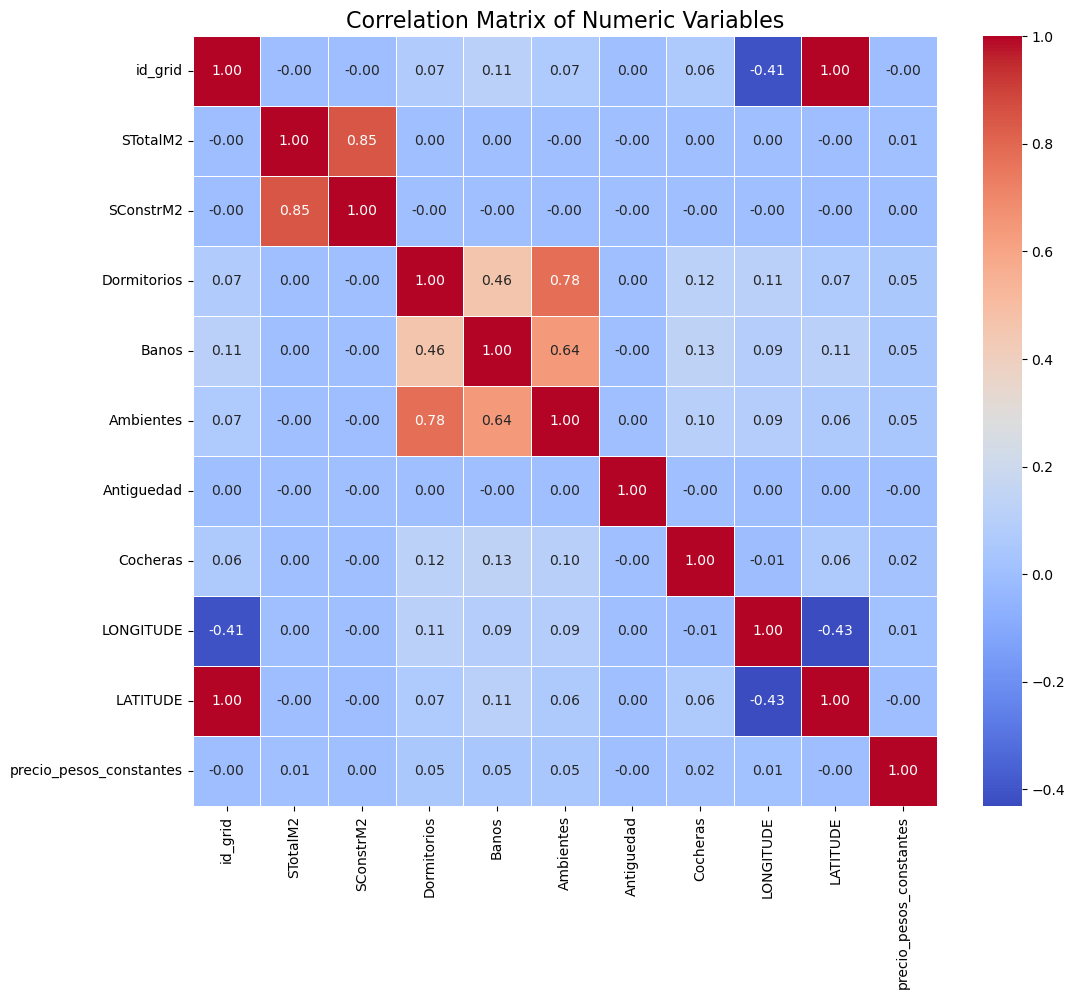

In [5]:
NUMERICAL_FEATURES = [
    COLS.ID_GRID, 
    COLS.SUP_TOTAL, 
    COLS.SUP_CONSTR, 
    COLS.DORMITORIOS, 
    COLS.BANOS, 
    COLS.AMBIENTES, 
    COLS.ANTIGUEDAD,
    COLS.COCHERAS,
    COLS.LONGITUD,
    COLS.LATITUD
]
plot_correlation_heatmap(df, NUMERICAL_FEATURES + [COLS.TARGET])

A priori, no hay correlación alguna entre las variables y el target, para ninguna feature. Esto probablemente se deba a outliers extremos, escalas muy diferentes, distribuciones sesgadas, o simplemente que la correlacion es no lineal. Tenemos que trabajar el dataset antes de seguir analizando

## Análisis de Precio
Análicemos un poco la variable objetivo:

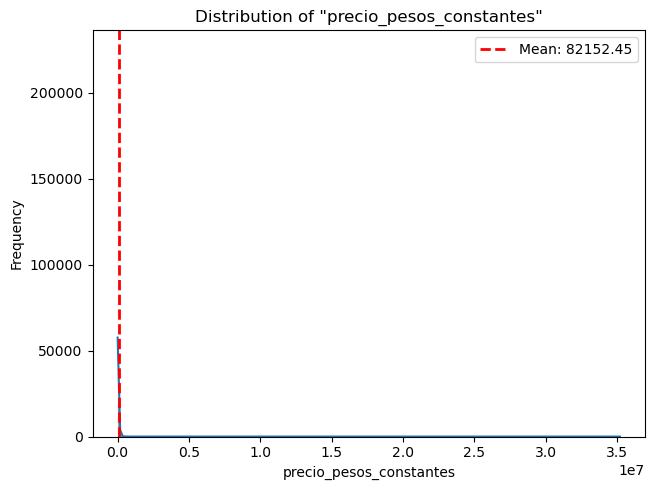

In [6]:
plot_histograms(df, [COLS.TARGET])

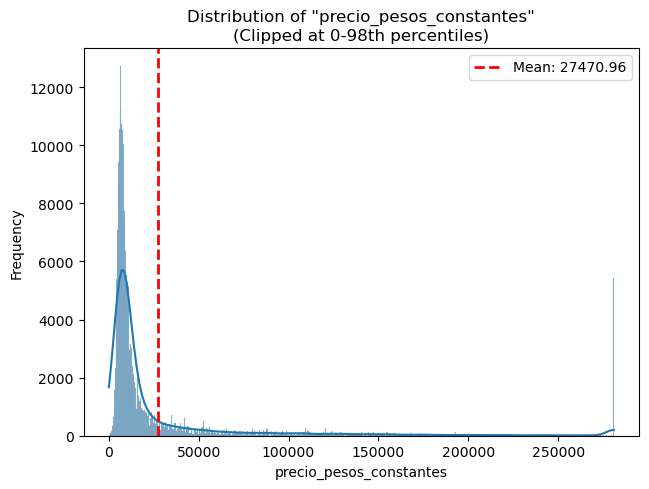

In [7]:
plot_histograms(df, [COLS.TARGET], clip_percentiles=(0.00, 0.98))

La variable objetivo (precio) está extremadamente sesgada hacia la izquierda. Esto quiere decir que la mayoría de los precios se encuentran en esa zona, mientras que hay unas pocas propiedades que tienen precios extremadamente altos. Veamos qué pasa si aplicamos el log:

In [8]:
df_log_precio = log_transform_features(df, [COLS.TARGET])

Applying log transformation to columns: precio_pesos_constantes


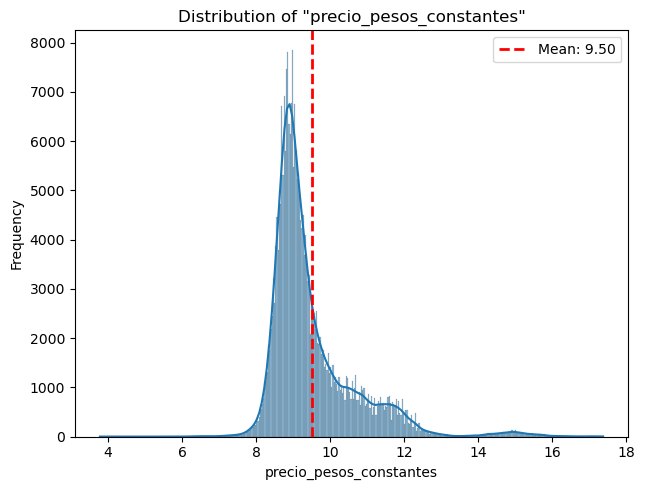

In [9]:
plot_histograms(df_log_precio, [COLS.TARGET])

La distribución de log(precio) es mucho más simpetrica y parecida a una distribución normal. Vamos a hacer que nuestro modelo prediga log(precio), lo cual va a facilitar mucho las predicciones.

## Análisis de Features Numéricas
Analicemos la distribución del resto de features numéricas:

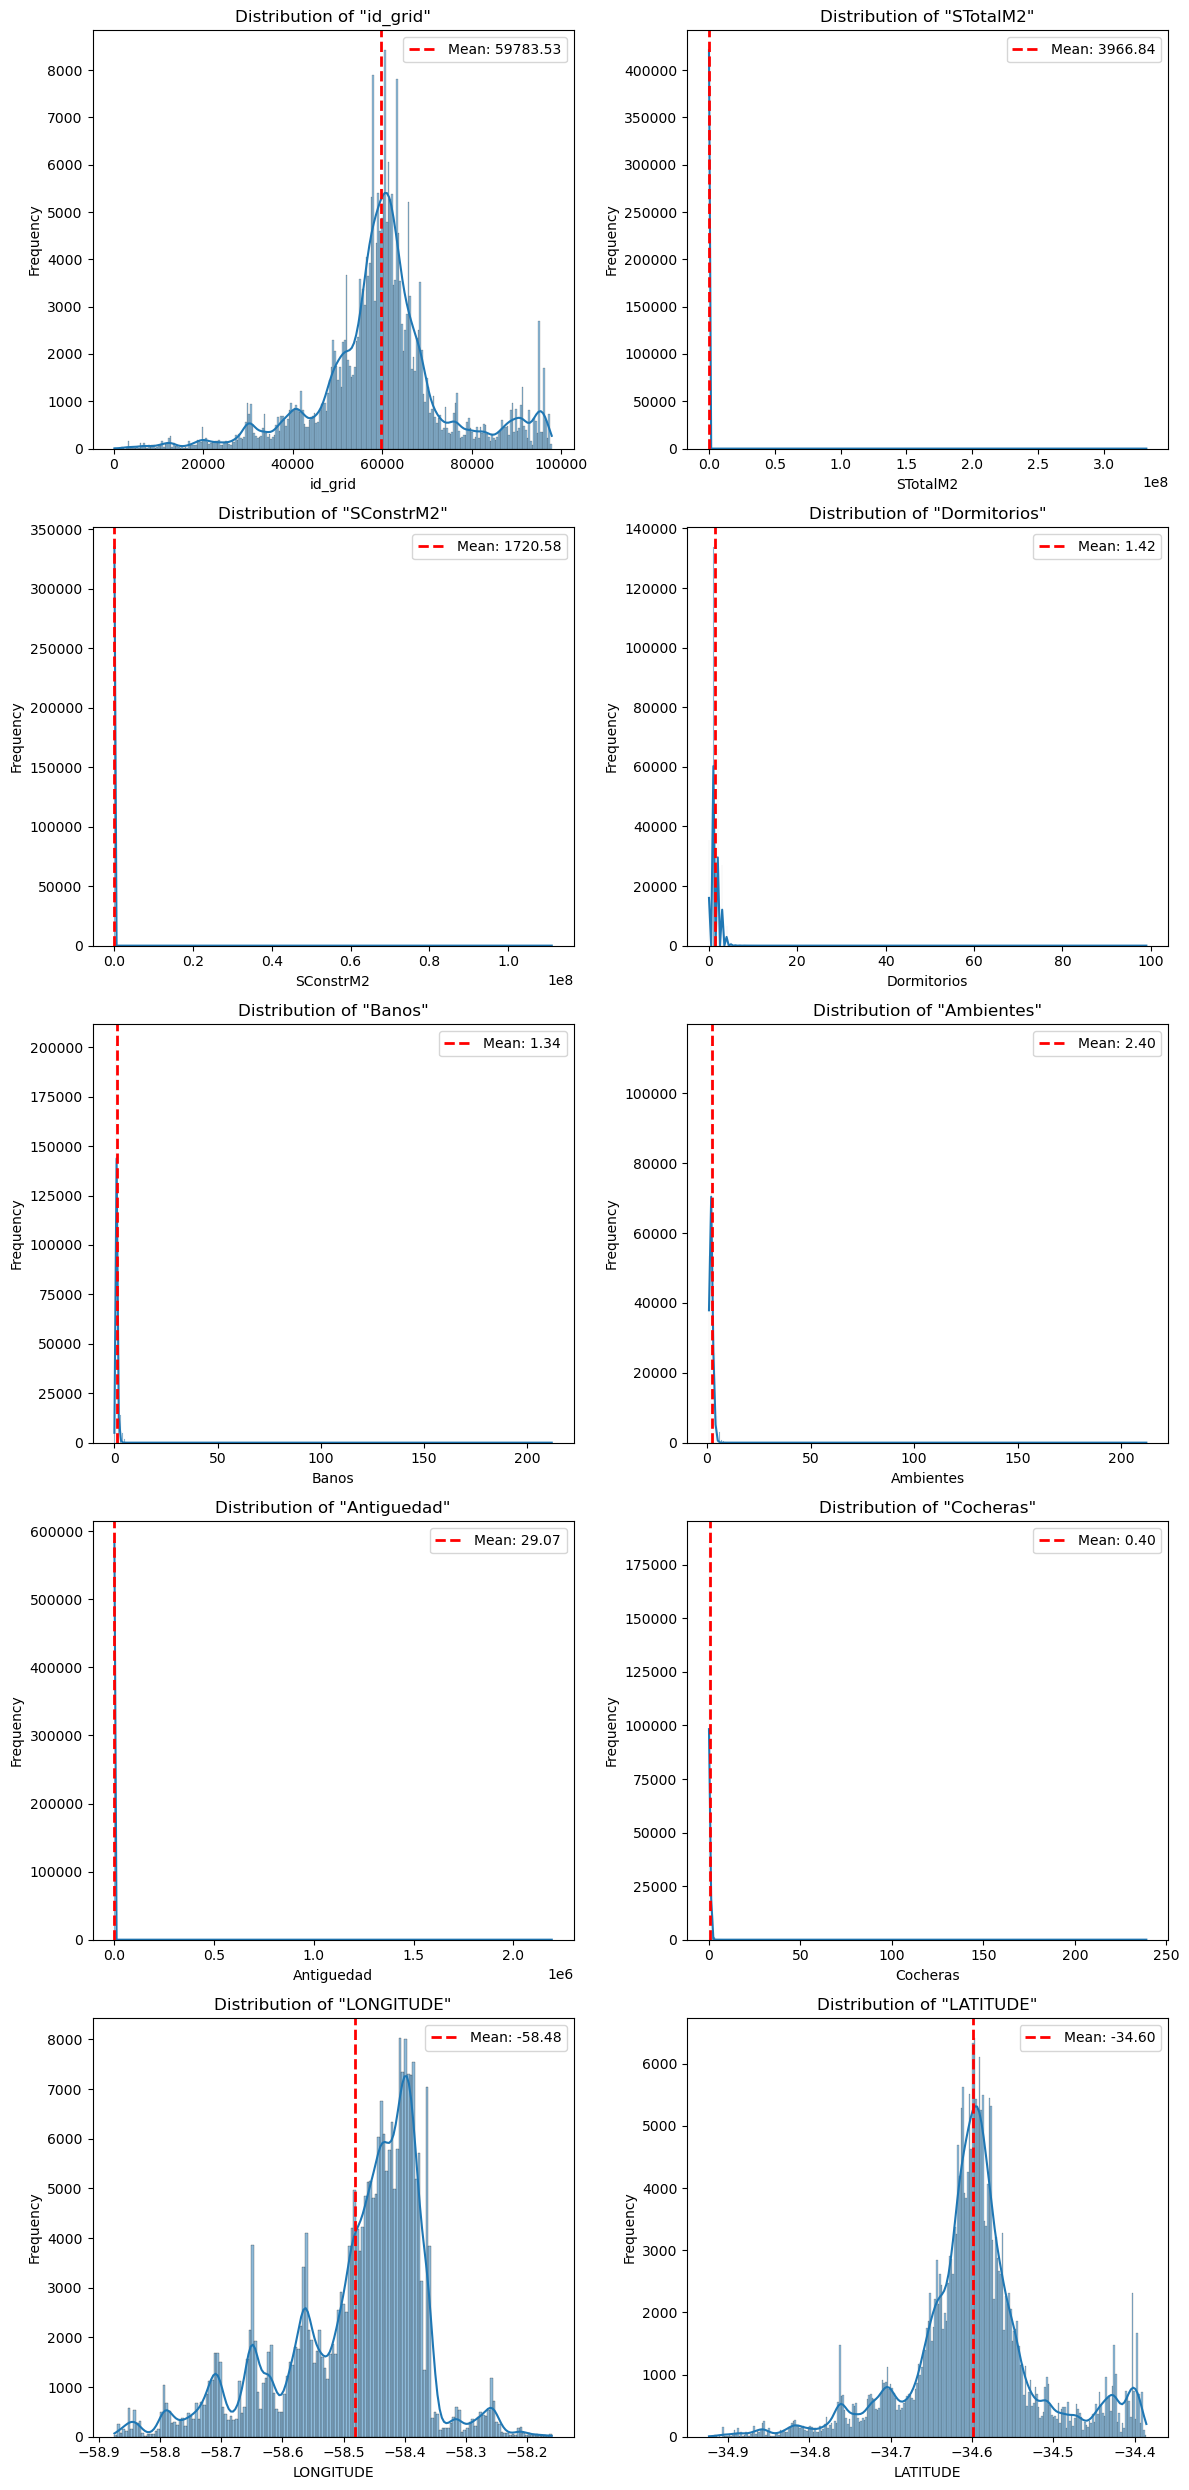

In [10]:
plot_histograms(df_log_precio, NUMERICAL_FEATURES, n_cols=2)

La mayoría de features muestran una asimetría extrema.

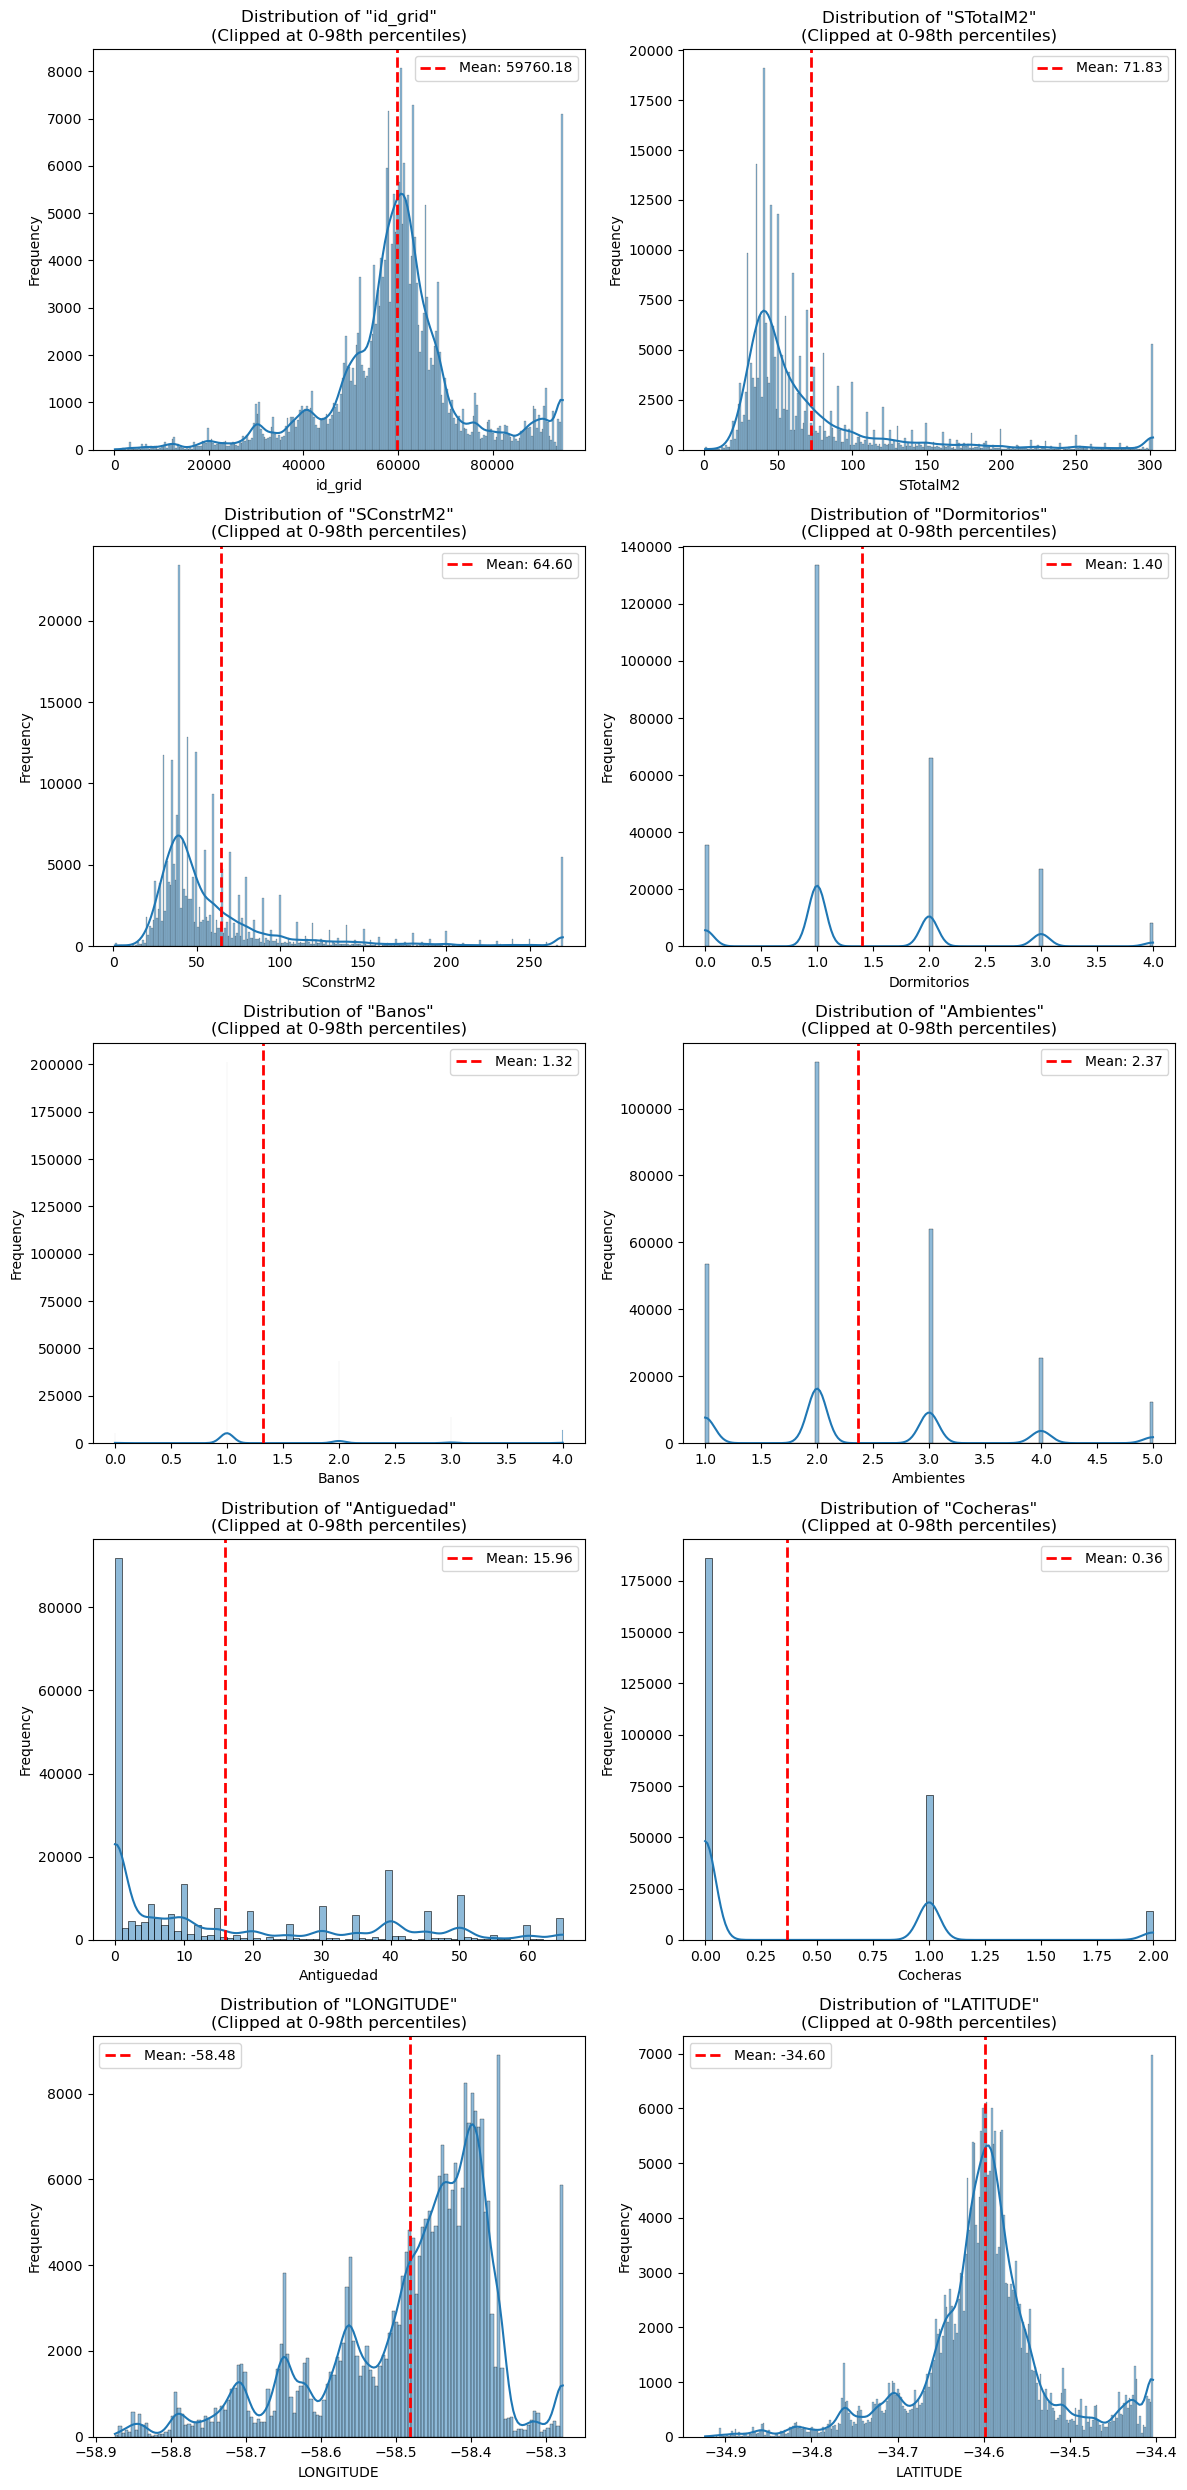

In [11]:
plot_histograms(df_log_precio, NUMERICAL_FEATURES, clip_percentiles=(0.00, 0.98), n_cols=2)

Al excluir los valores realmente extremos, vemos que muchas variables pasan de ser aparentemente numéricas a categóricas. Esto sucede con Dormitorios, Banos, Ambientes, Cocheras. Al excluir outliers extremos, estas variables se mueven únicamente en valores discretos entre 0 y 6. Por ello, asumimos que esos valores extremos (que aplican solo a algunos datos) son erróneos. Vamos a capearlos al percentil más cercano

In [12]:
OUTLIER_COLS = [COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.COCHERAS, COLS.ANTIGUEDAD]
df_capped, _ = cap_outliers(df_log_precio, OUTLIER_COLS, percentiles=(0.00, 0.98))

Capping outliers for columns: Dormitorios, Banos, Ambientes, Cocheras, Antiguedad


Además, actualizamos nuestras columnas numéricas para no incluir las recién nombradas (pues pasan a ser categóricas al tener solo algunos valores posibles)

In [13]:
NUMERICAL_FEATURES = [
    COLS.ID_GRID, COLS.SUP_TOTAL, COLS.SUP_CONSTR, COLS.ANTIGUEDAD, COLS.LONGITUD, COLS.LATITUD
]

CATEGORICAL_FEATURES = [
    COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.AMOBLADO, COLS.BUSINESS, COLS.GIMNASIO, COLS.LAUNDRY, COLS.CALEFACCION, COLS.AIRE, COLS.RECEPCION, COLS.ESTACIONAMIENTO, COLS.JACUZZI, COLS.SEGURIDAD, COLS.PILETA, COLS.COCHERAS, COLS.TENNIS, COLS.PROVINCIA, COLS.CONDICION, COLS.BARRIO, COLS.ANIO, COLS.MES, "SUM"
]

Todavía tenemos problemas con algunas variables numéricas. Por ejemplo, la superficie y antigüedad están muy sesgadas y afectadas por outliers. Veamos si aplicar una transformación logarítmica ayuda a mejorar esto

Applying log transformation to columns: STotalM2, SConstrM2, Antiguedad


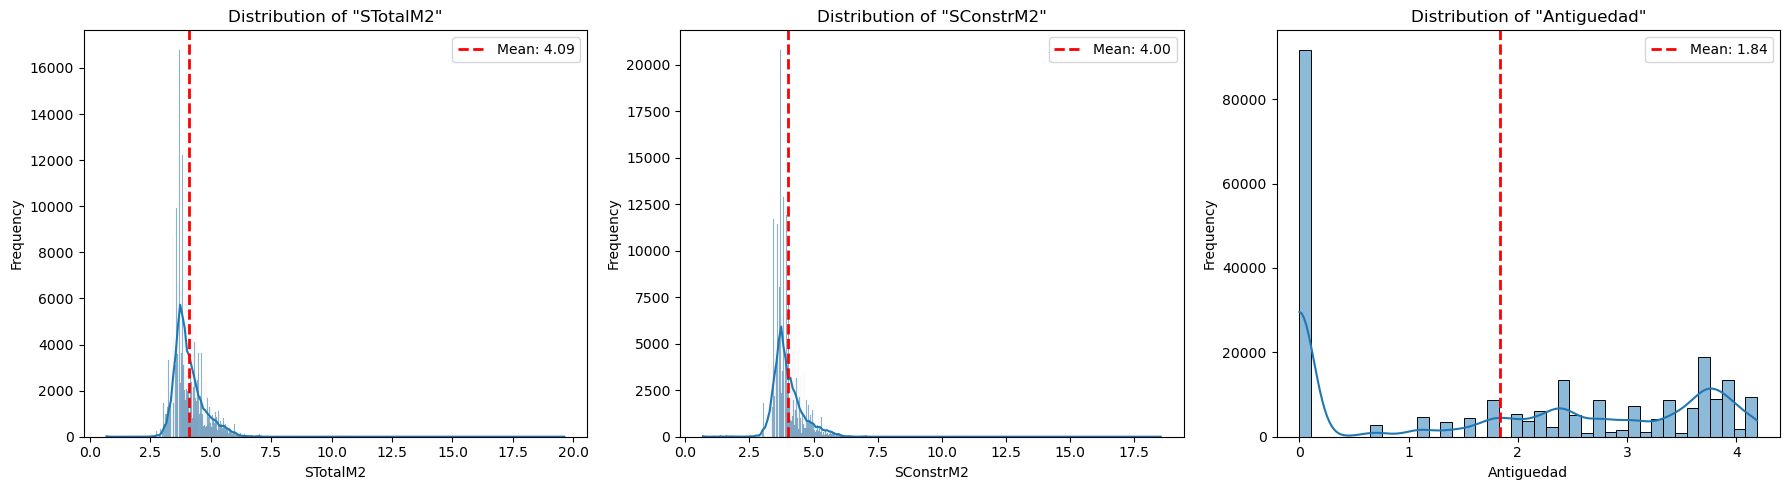

In [14]:
OUTLIER_COLS = [COLS.SUP_TOTAL, COLS.SUP_CONSTR, COLS.ANTIGUEDAD]
df_log = log_transform_features(df_capped, OUTLIER_COLS)
plot_histograms(df_log, OUTLIER_COLS)

La situación mejoró, pero siguen habiendo valores demasiado extremos que probablemente se correspondan a errores de medición (por ejemplo para superficie, hay valores demasiado grandes que podrían corresponderse con la superficie del edificio entero en lugar de la propiedad). Para Antiguedad, el valor máximo es alrededor de 500 años lo cual podría no ser un error. Entonces, cappeemos los outliers extremos en superficie

Capping outliers for columns: STotalM2, SConstrM2


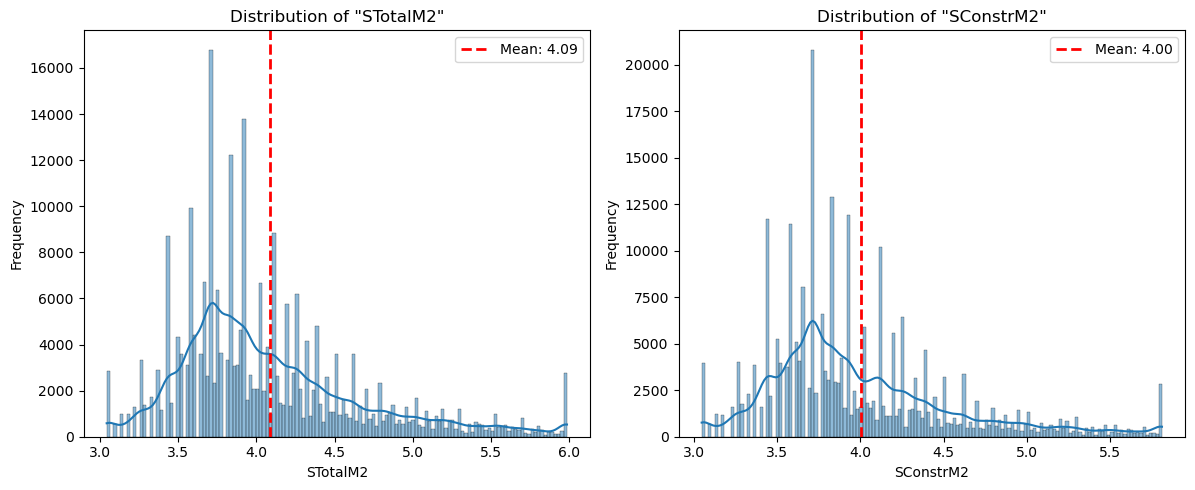

In [15]:
SUP_COLS = [COLS.SUP_TOTAL, COLS.SUP_CONSTR]
df_sup_capped, _ = cap_outliers(df_log, SUP_COLS, percentiles=(0.01, 0.99))
plot_histograms(df_sup_capped, SUP_COLS)

Ahora sí las distribuciones son más gaussianas lo cual va a ayudar a nuestros modelos. Finalmente, apliquemos una estandarización para que los datos se parezcan más a una normal estándar y tengan magnitudes similares:

Standardizing columns: id_grid, STotalM2, SConstrM2, Antiguedad, LONGITUDE, LATITUDE


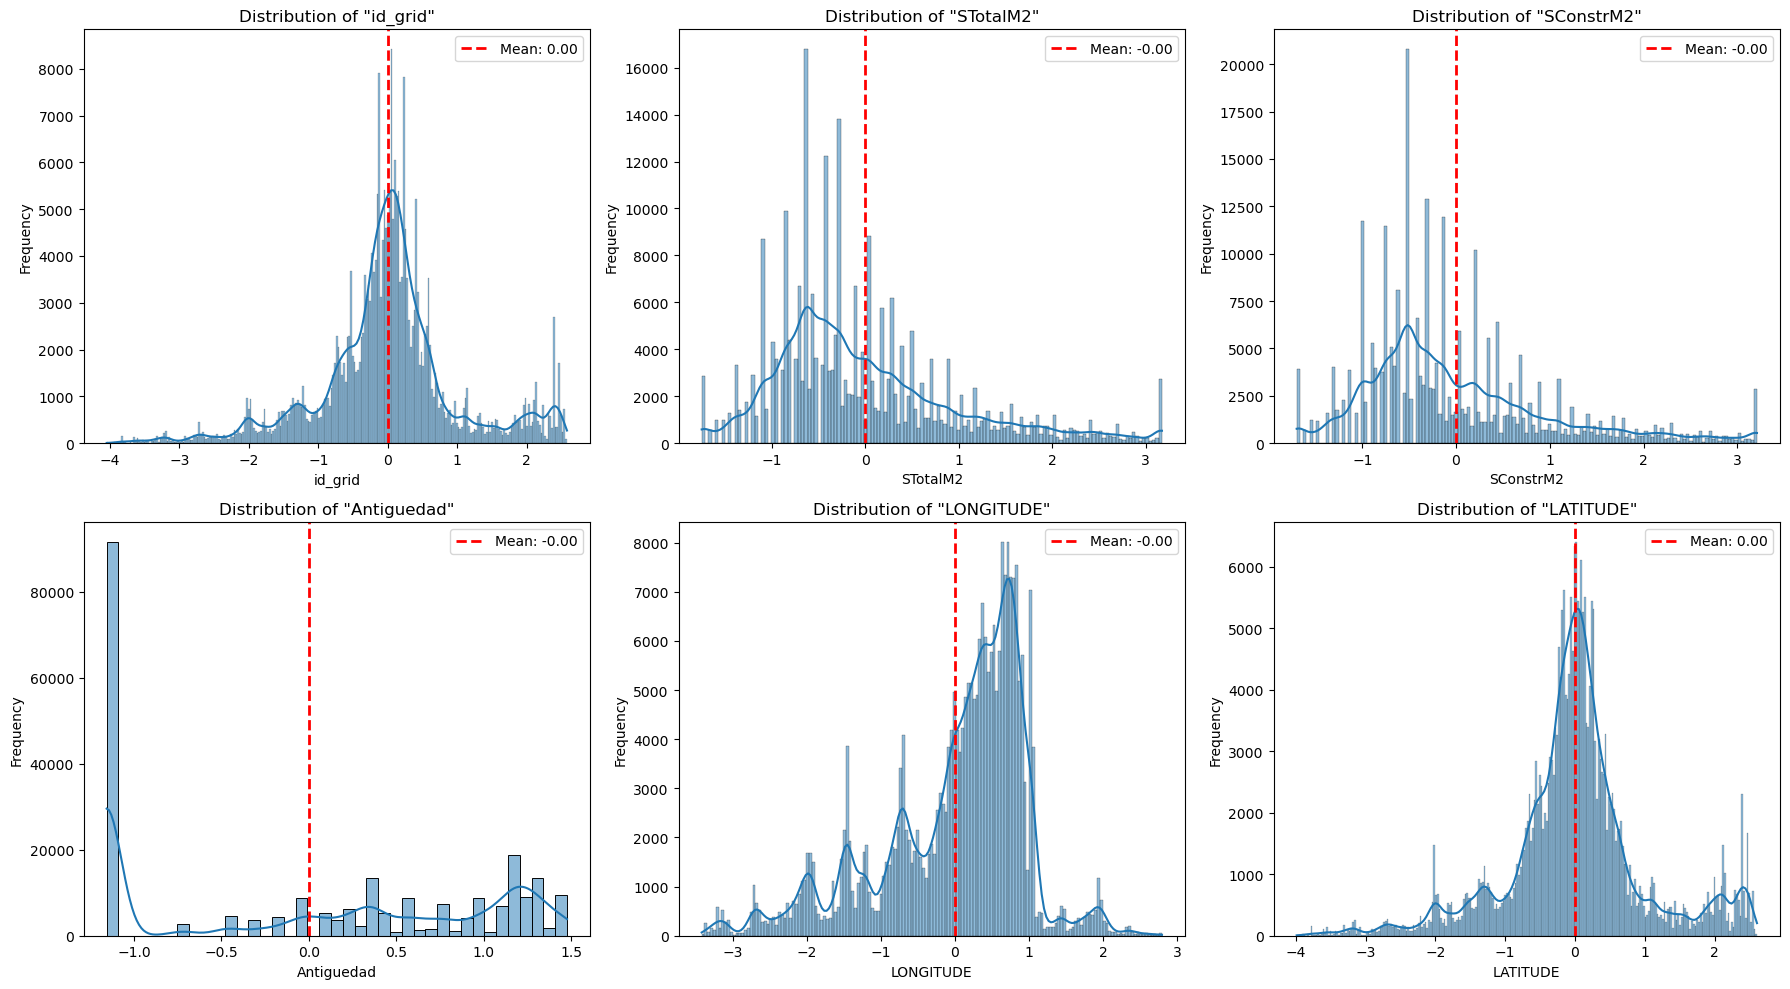

In [16]:
df_std, _ = standardize_features(df_sup_capped, NUMERICAL_FEATURES)
plot_histograms(df_std, NUMERICAL_FEATURES)

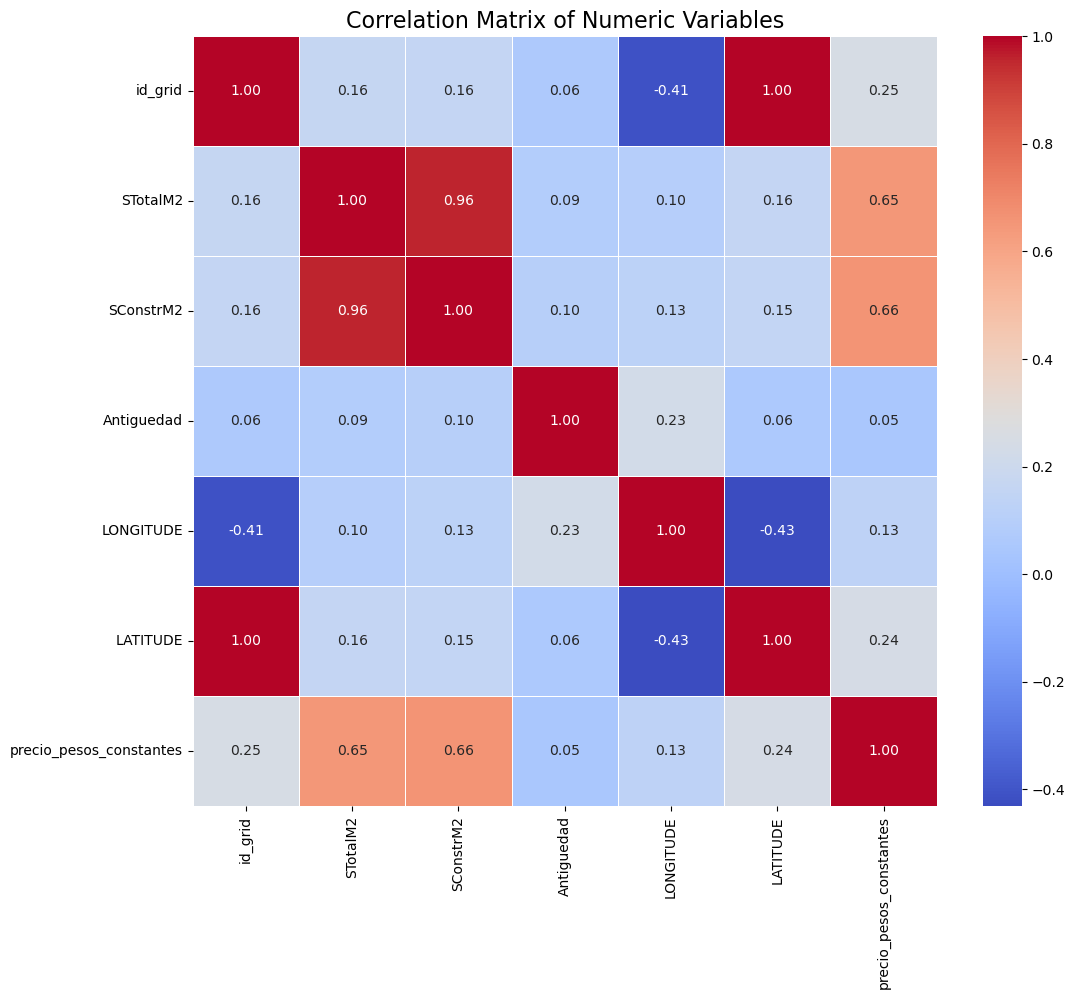

In [17]:
plot_correlation_heatmap(df_std, NUMERICAL_FEATURES + [TARGET])

Ahora sí la matriz de heatmap empieza a mostrar algunas correlaciones, especialmente en las features de superficie. Estas dos están altamente correlacionadas entre sí, lo cual nos indica que probablemente contengan información muy redundante y quizás podamos sacar a una de ellas.

Las features de ubicación (id_grid, longitud, latitud) muestran algo de correlación. Antiguedad no pareciera tener correlacion lineal con el target
- Otra cosa a notar es que id_grid tiene una correlación del 100% con latitud. Esto probablemente signifique que el id del polígono sea exactamente igual que la latitud, y nos podamos deshacer de él

Conclusiones:
- Eliminar id_grid ya que no aporta al problema
- Eliminar SConstrM2 ya que contiene información casi idéntica a STotalM2

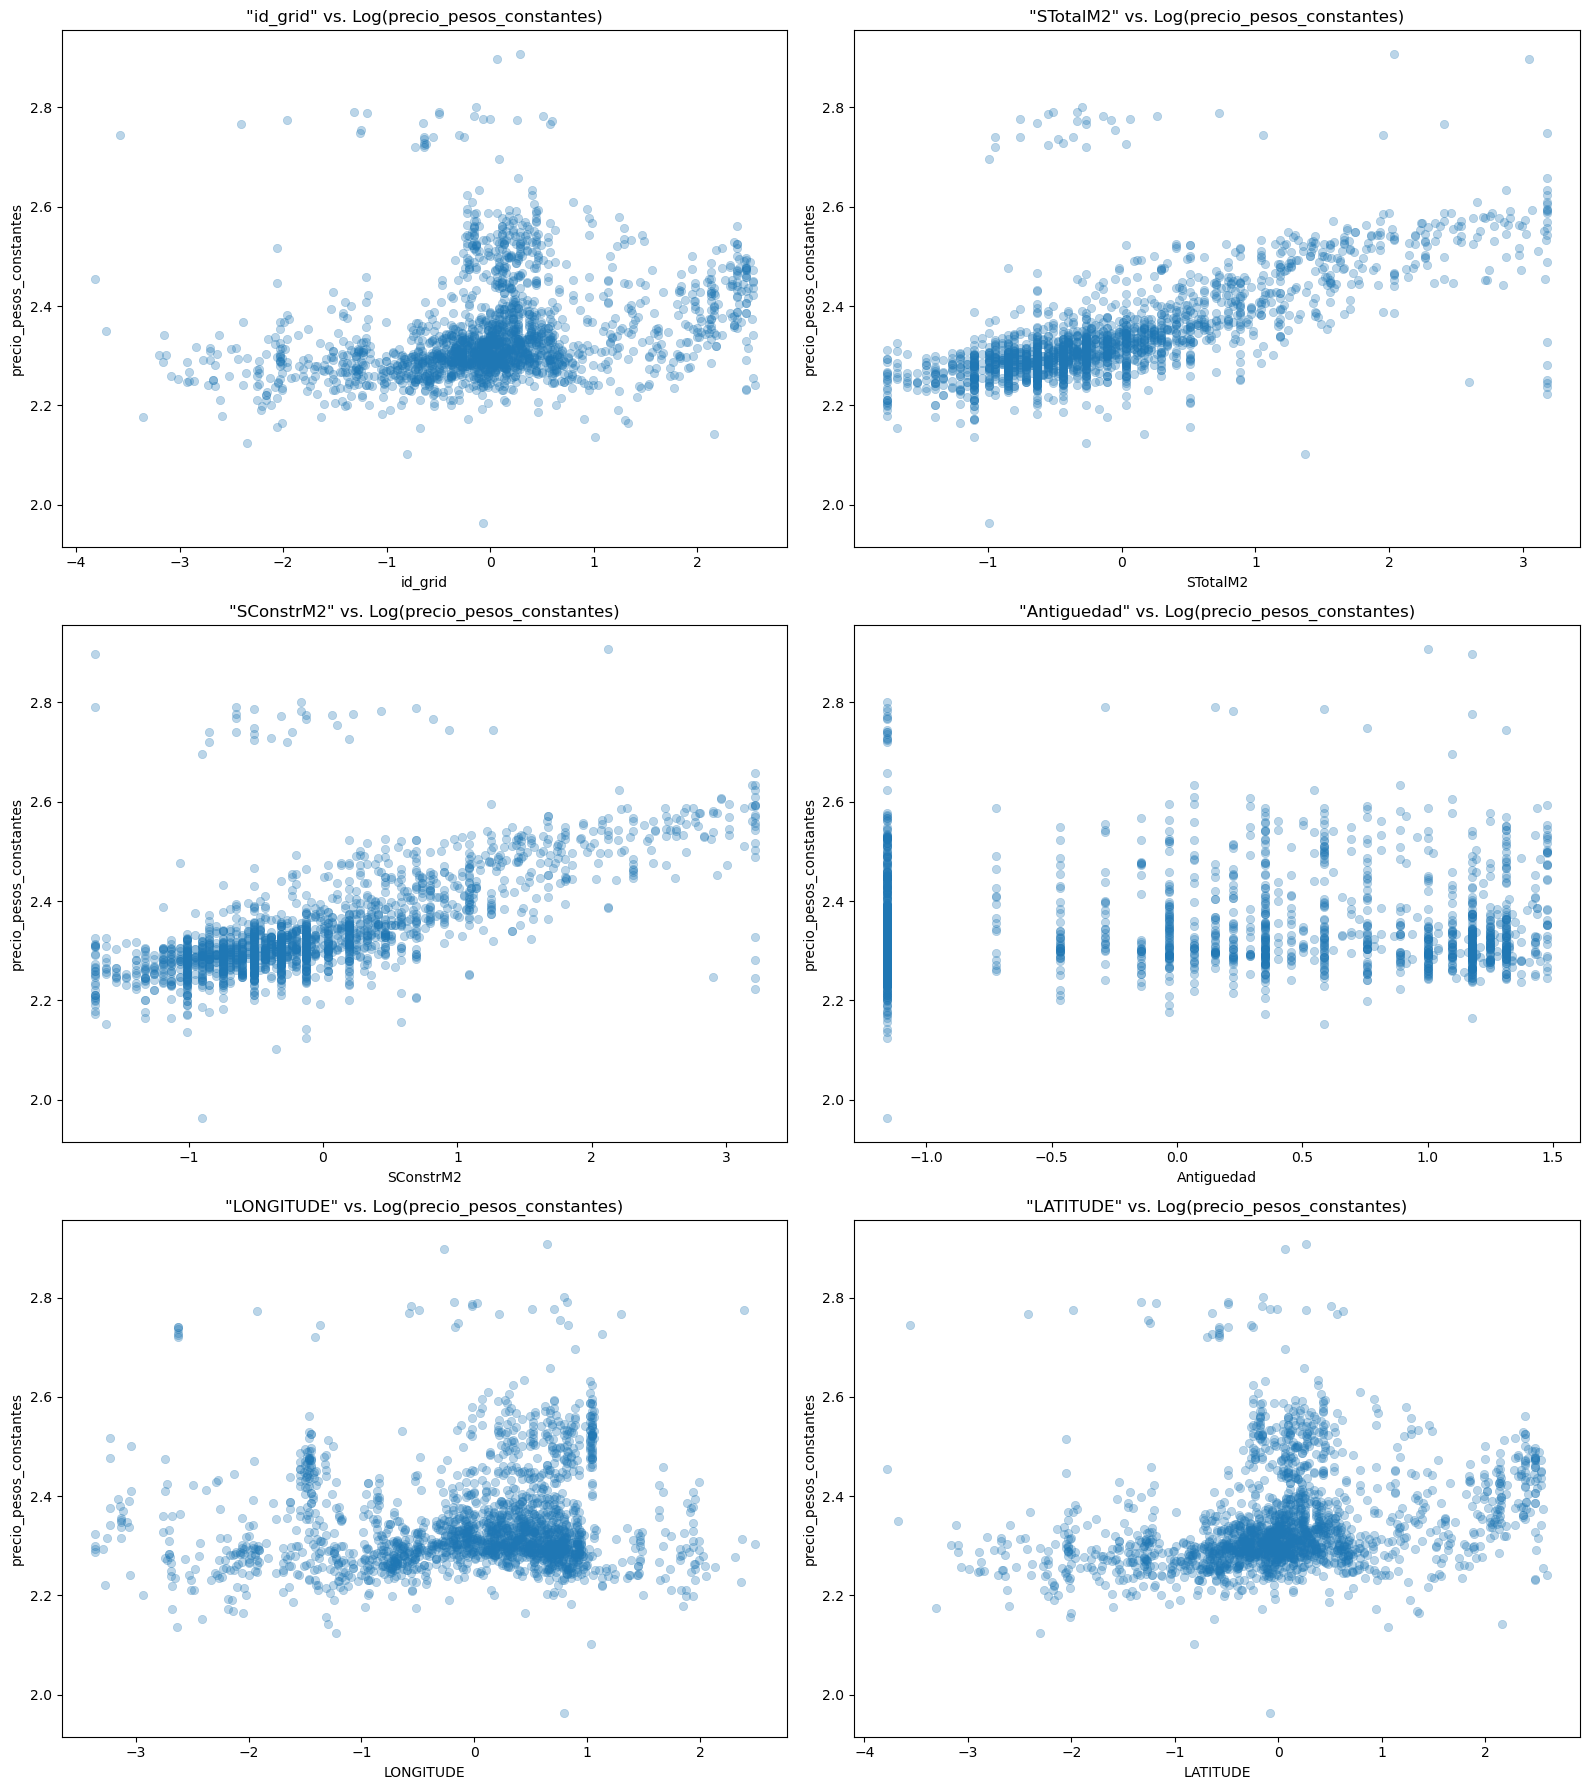

In [18]:
plot_numeric_vs_target(numeric_cols=NUMERICAL_FEATURES, target_col=TARGET, df=df_std)

En los scatter plots vemos cosas similares a la matriz de correlación:
- Las variables de superficie muestran cierta correlación lineal, siendo ambas variables muy parecidas. Podemos con seguridad eliminar alguna de las dos pues son redundantes
- Las variables de ubicación también muestran cierta correlación, con precios más altos cerca del cero. Lo mismo con id_grid. Podemos eliminar ésta última ya que es exactamente igual que latitud.

## Análisis de Features Categóricas

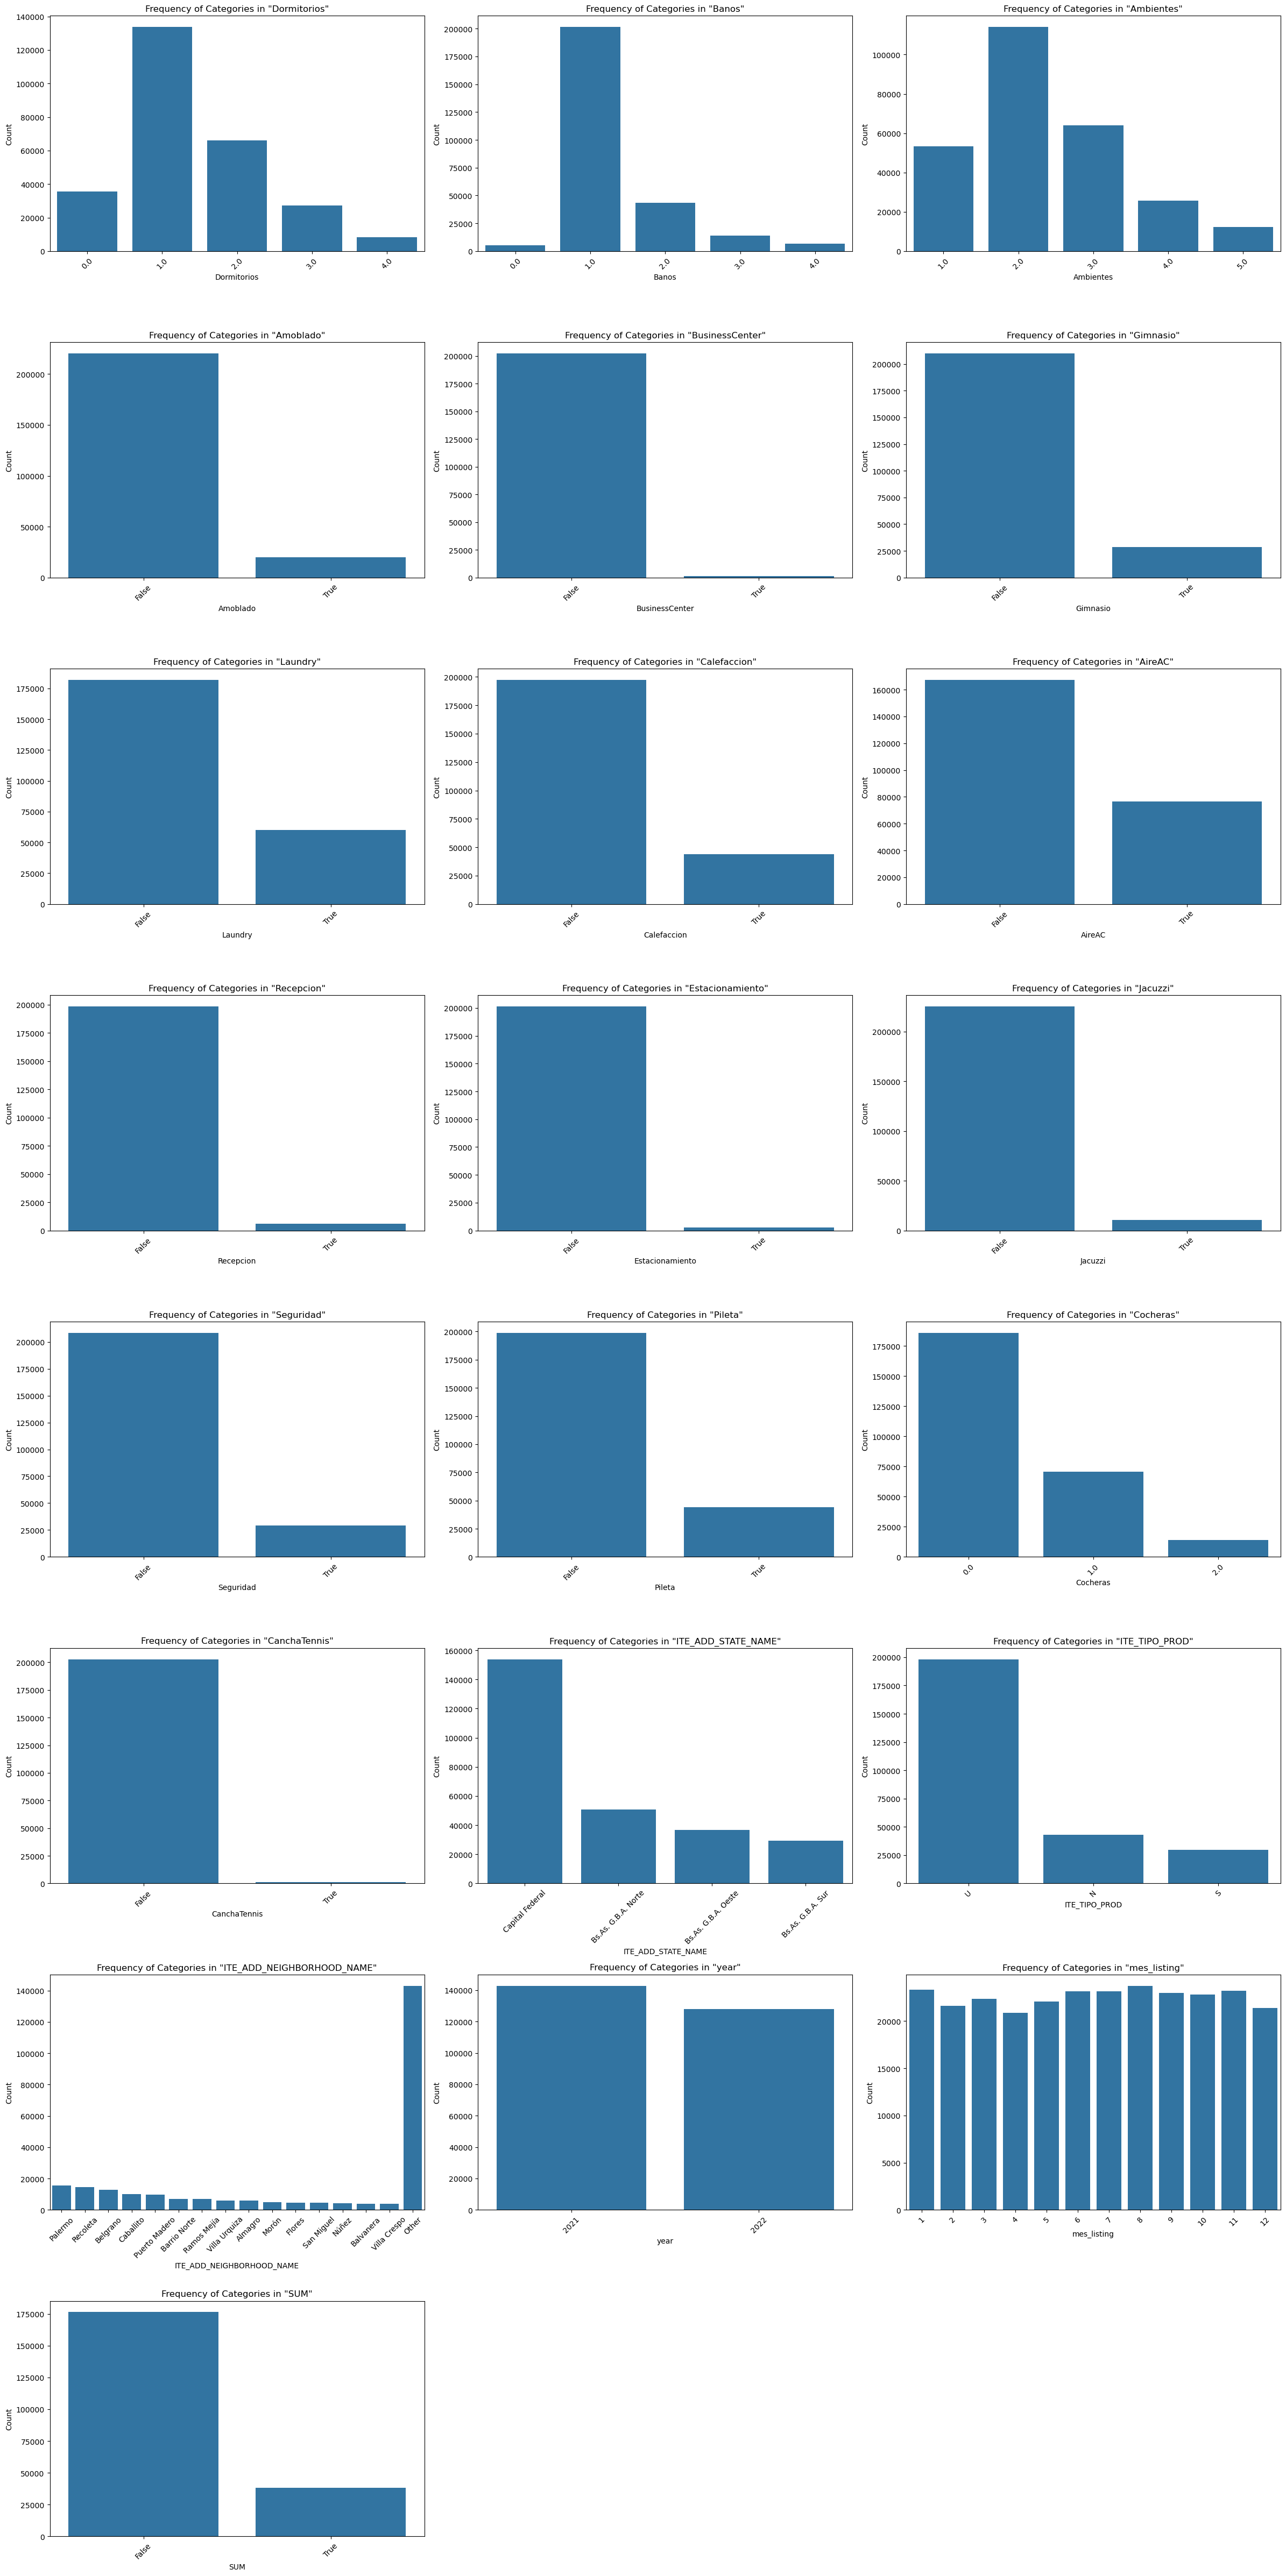

In [19]:
plot_bar_charts(df_std, CATEGORICAL_FEATURES, n_cols=3)

Insights:
- Variables booleanas muy desbalanceadas. Especialmente algunas relacionadas con amenities de lujo, tienen un desbalance extremo, donde solo están presentes en algunas pocas propiedades.
- Otras variables categoricas como Ambientes y Dormitorios tienen una forma aproximadamente gaussiana. Probablemente no sean un problema.

Comparemos el impacto que tiene cada una de las features booleanas sobre el precio
- La métrica que se va a utilizar es la diferencia de medianas entre las muestras que son True y las muestras que son False. Cuanto más grande es la diferencia entre medianas, podemos decir que más grande es el impacto que tiene la feature sobre el precio

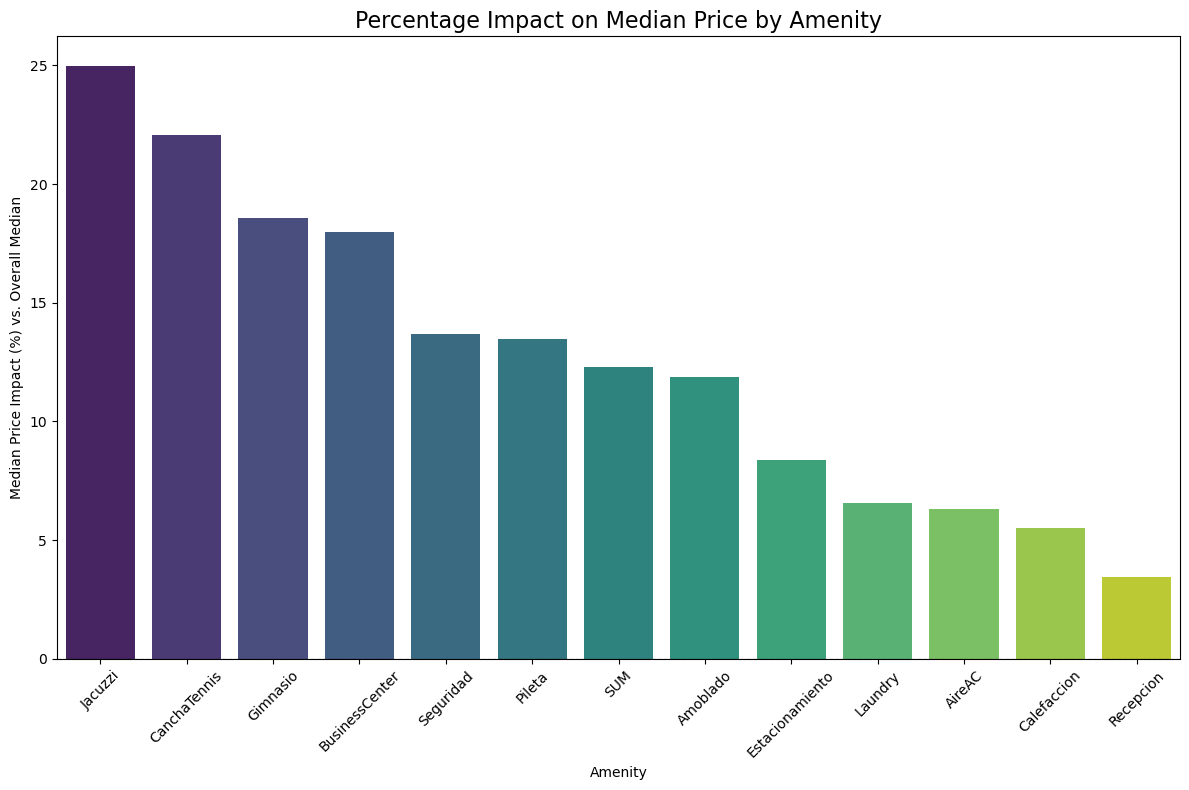

In [20]:
BOOLEAN_COLS = [COLS.AMOBLADO, COLS.BUSINESS, COLS.GIMNASIO, COLS.LAUNDRY, COLS.CALEFACCION, COLS.AIRE, COLS.RECEPCION, COLS.ESTACIONAMIENTO, COLS.JACUZZI, COLS.SEGURIDAD, COLS.PILETA, COLS.TENNIS, "SUM"]
plot_median_price_impact(df_std, BOOLEAN_COLS, TARGET)

Insights:
- Recepcion aplica a muy pocas propiedades y tiene muy bajo impacto. La eliminamos
- Amenities de lujo (Jacuzzi, CanchaTennis) tienen el mayor impacto sobre el precio, lo cual es esperable

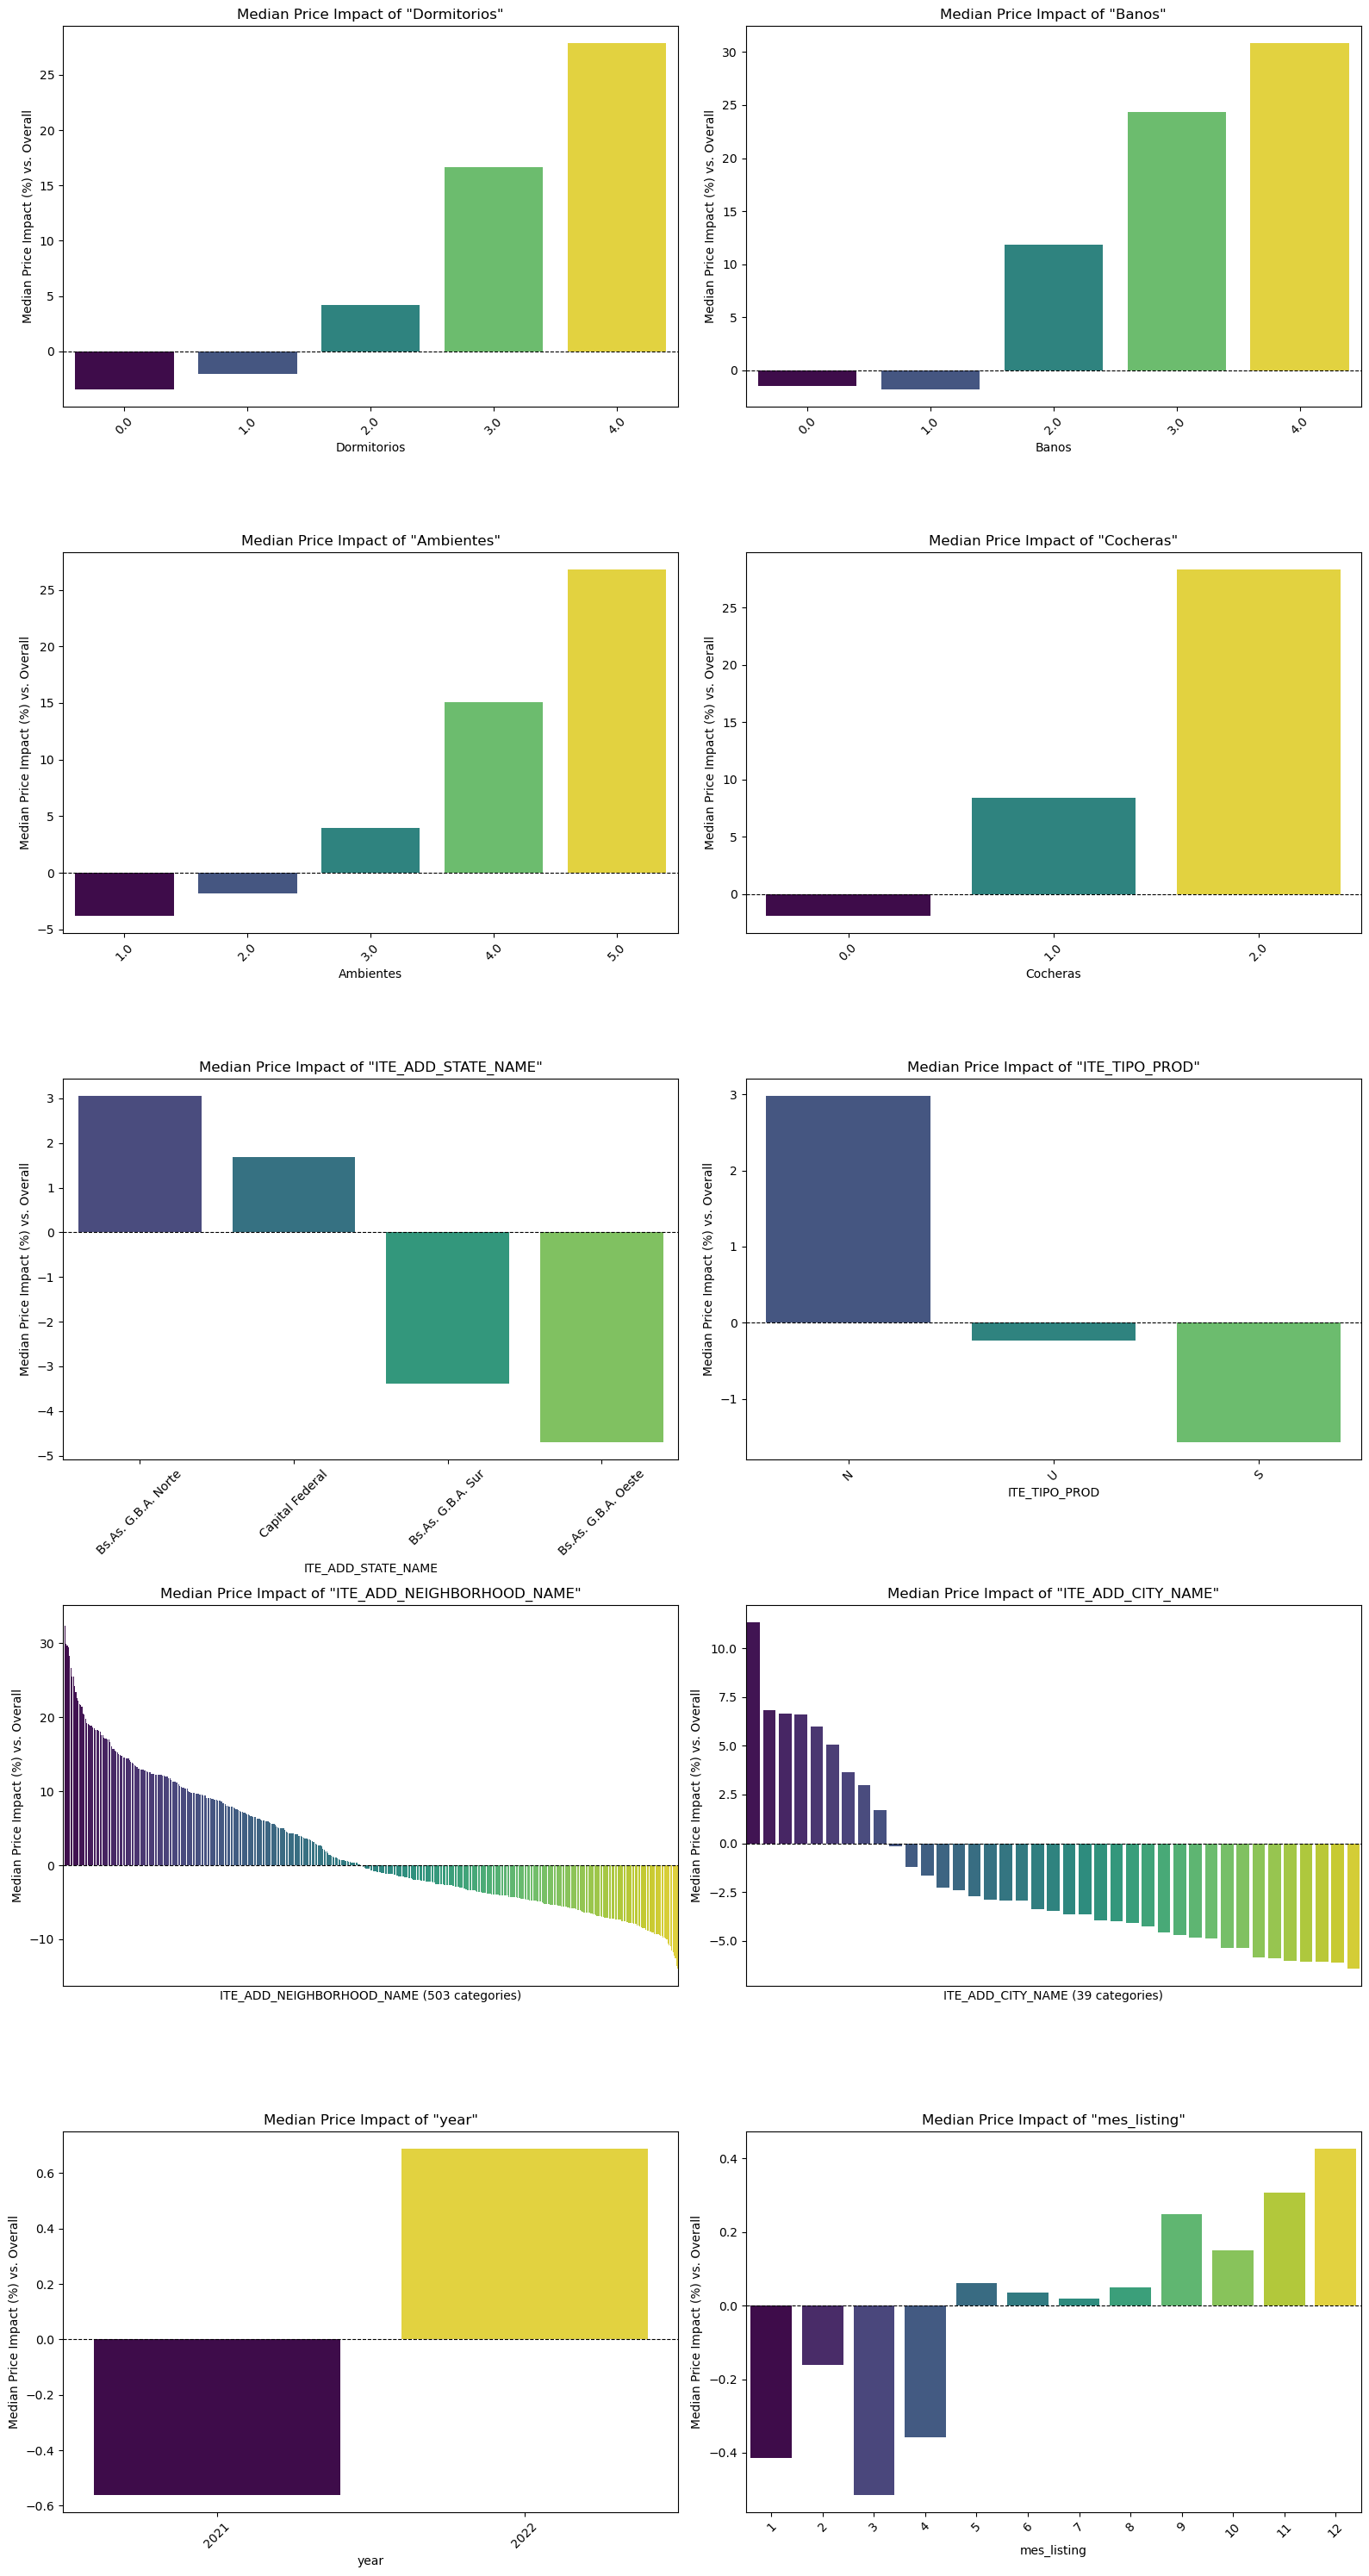

In [21]:
PURELY_CATEGORICAL_COLS=[COLS.DORMITORIOS, COLS.BANOS, COLS.AMBIENTES, COLS.COCHERAS, COLS.PROVINCIA, COLS.CONDICION, COLS.BARRIO, COLS.CIUDAD, COLS.ANIO, COLS.MES]
plot_categorical_impact(df_std, PURELY_CATEGORICAL_COLS, TARGET)

Insights:
- Una mayor cantidad de dormitorios, baños, ambientes y cocheras tiende a subir el precio
- Las propiedades nuevas tienen en promedio un precio alrededor de 3% mayor que el promedio
- La categoría de zonas muestra claramente como las propiedades de Zona Norte son las más costosas, seguidas por CABA, Zona sur y Zona Oeste
- Los precios subieron en un pequeño porcentaje (en términos reales) de 2021 a 2022
- Ppareciera haber una muy leve correlacion entre el mes del año en el que se publicó la propiedad y el precio
- El barrio de la propiedad pareciera tener un impacto _muy_ alto en el precio

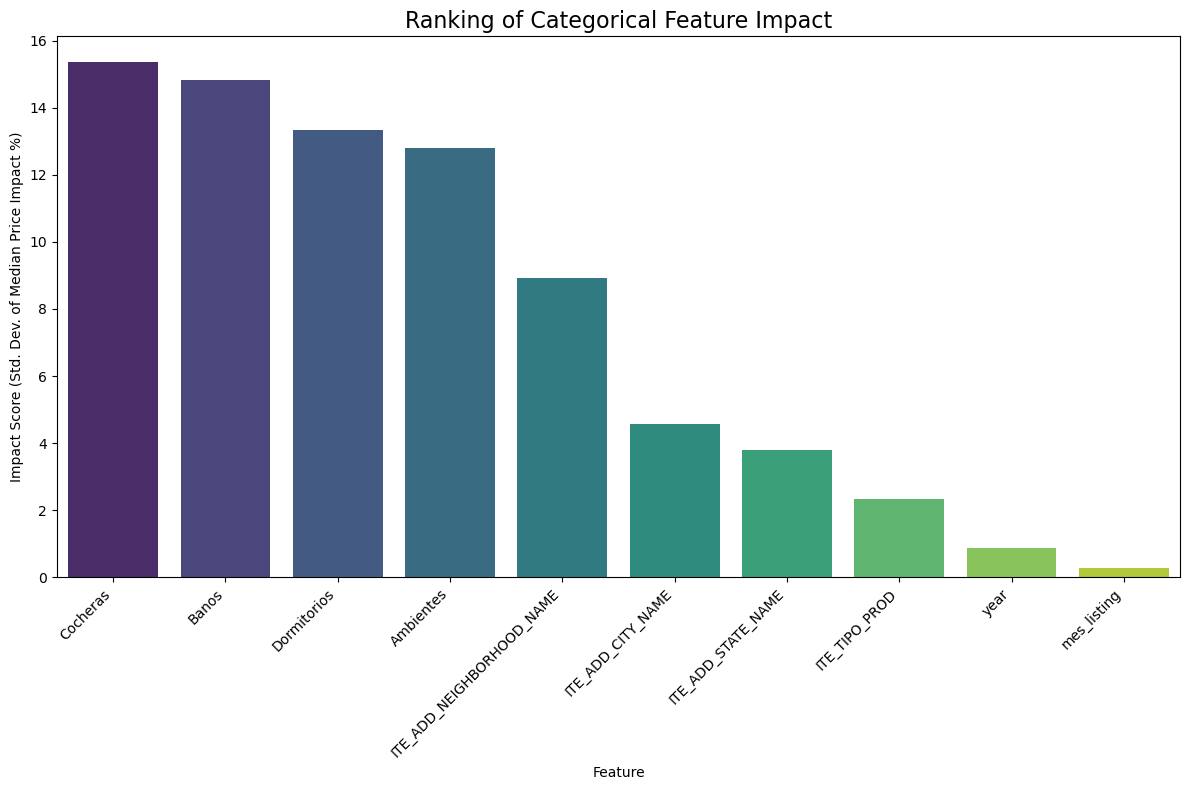

In [22]:
plot_feature_impact_ranking(df_std, PURELY_CATEGORICAL_COLS, TARGET)

Este gráfico intenta comparar el efecto en el precio que tiene cada variable categórica. Para ello, se utiliza como métrica la desviación estandar del efecto sobre la media del precio de cada categoría, para cada columna.

Cocheras, baños, ambientes, dormitorios son las variables con el mayor impacto. Le siguen las variables relacionadas con la ubicación. Las relacionadas con la fecha de la publicación son las que menos impacto tienen.

## Análisis Geoespacial

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


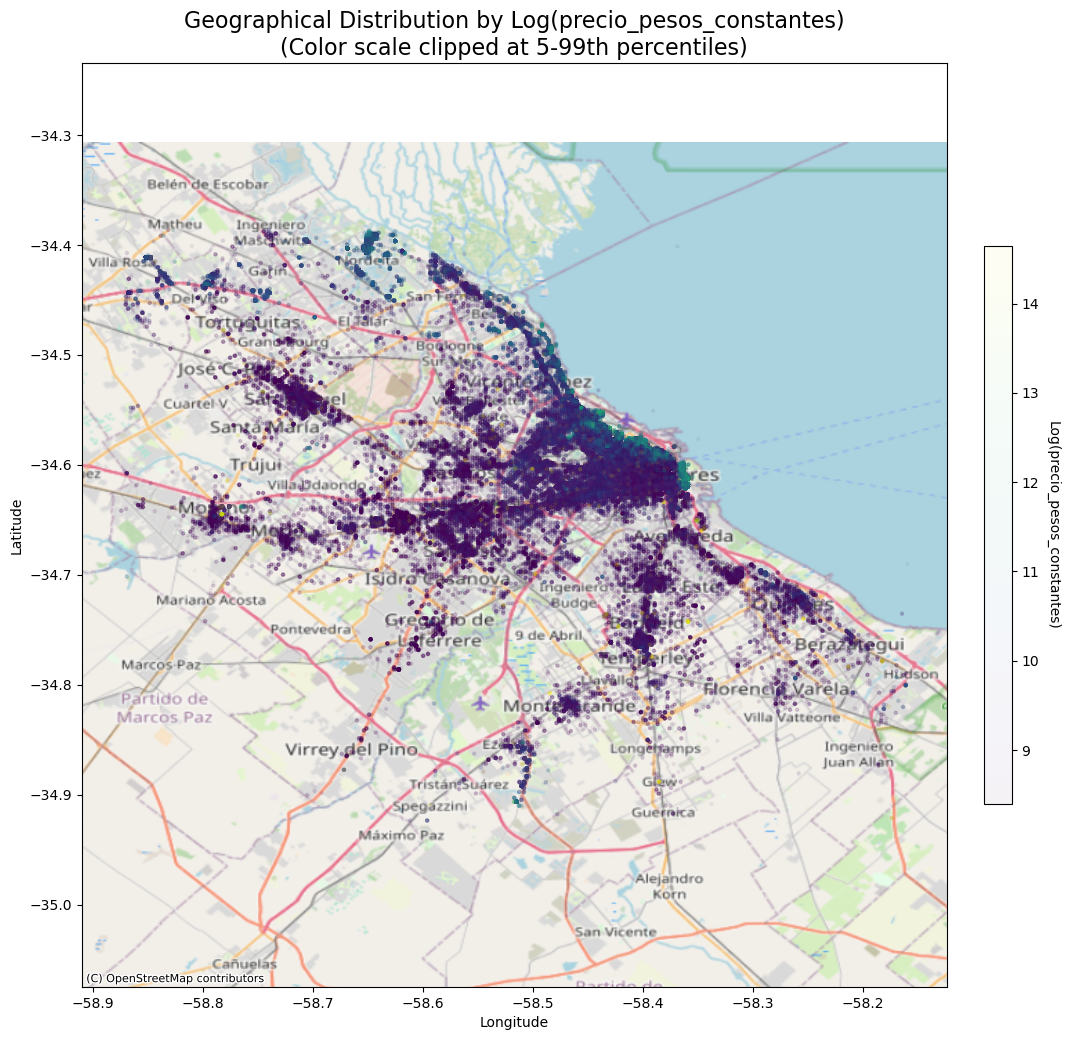

In [23]:
plot_geo_scatterplot(
    df,
    geo_cols=(COLS.LONGITUD, COLS.LATITUD),
    color_col=TARGET,
    log_scale=True,
    clip_percentiles=(0.05, 0.99),
    cmap='viridis',
    add_basemap=True,
    alpha=0.05
)

En el gráfico se ve claramente como una angosta franja de la zona norte de la ciudad y del conurbano contiene a las propiedades con el mayor precio. Alejándose de esta franja, las propiedades bajan mucho de precio, a excepcion de algunas zonas del conurbano que probablemente se correspondan con barrios cerrados.

## Análisis de datos faltantes.

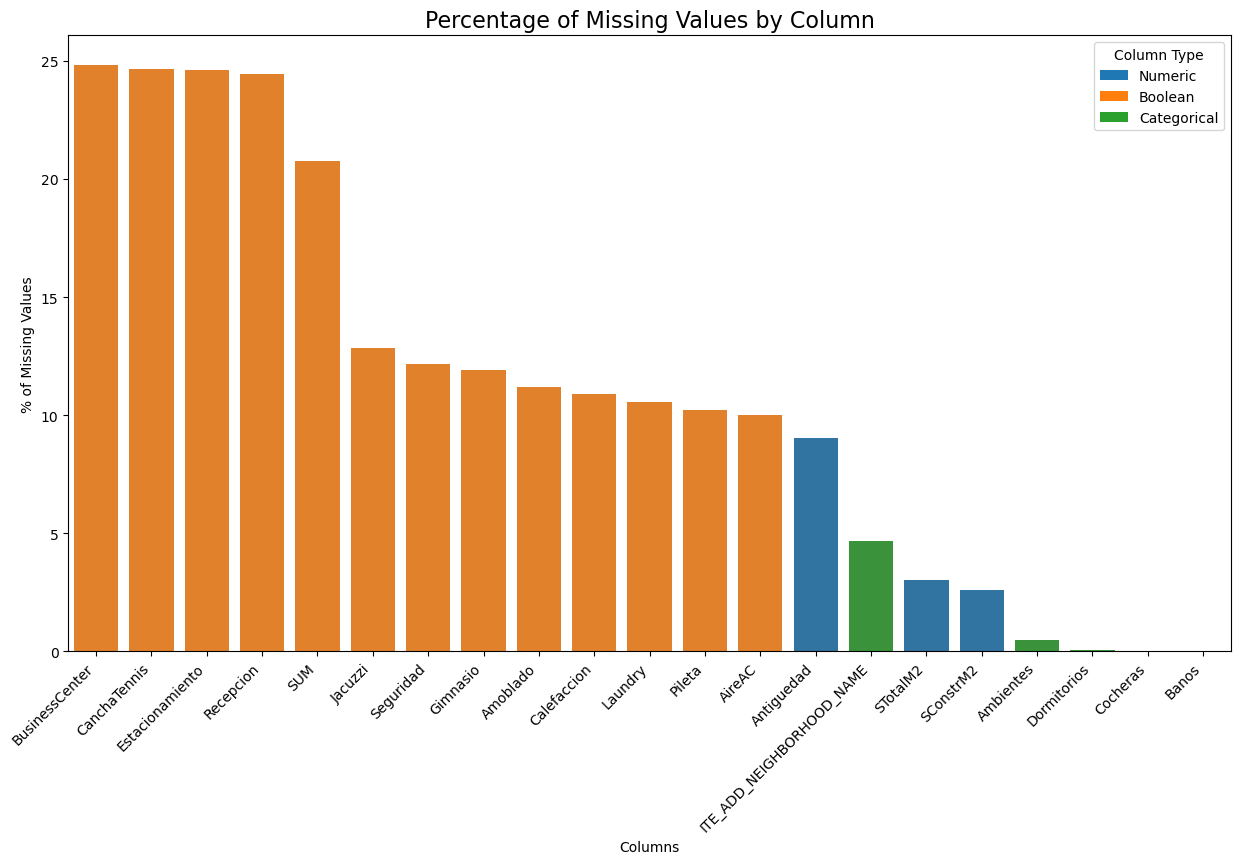


Info: The following 9 columns are not shown because they have no missing values:
id_grid, ITE_ADD_CITY_NAME, ITE_ADD_STATE_NAME, ITE_TIPO_PROD, LONGITUDE, LATITUDE, precio_pesos_constantes, year, mes_listing


In [24]:
plot_missing_values(df_std, numeric_cols=NUMERICAL_FEATURES, bool_cols=BOOLEAN_COLS, cat_cols=PURELY_CATEGORICAL_COLS)

Las features con menos NaNs son Baños, Cocheras, Domritorios y Ambientes, que a la vez son las features que más impacto tienen en el precio. Al ser tan pocas muestras las que tienen estos datos faltantes, y al ser tan importantes estos datos, lo mejor será directamente descartar estas filas.



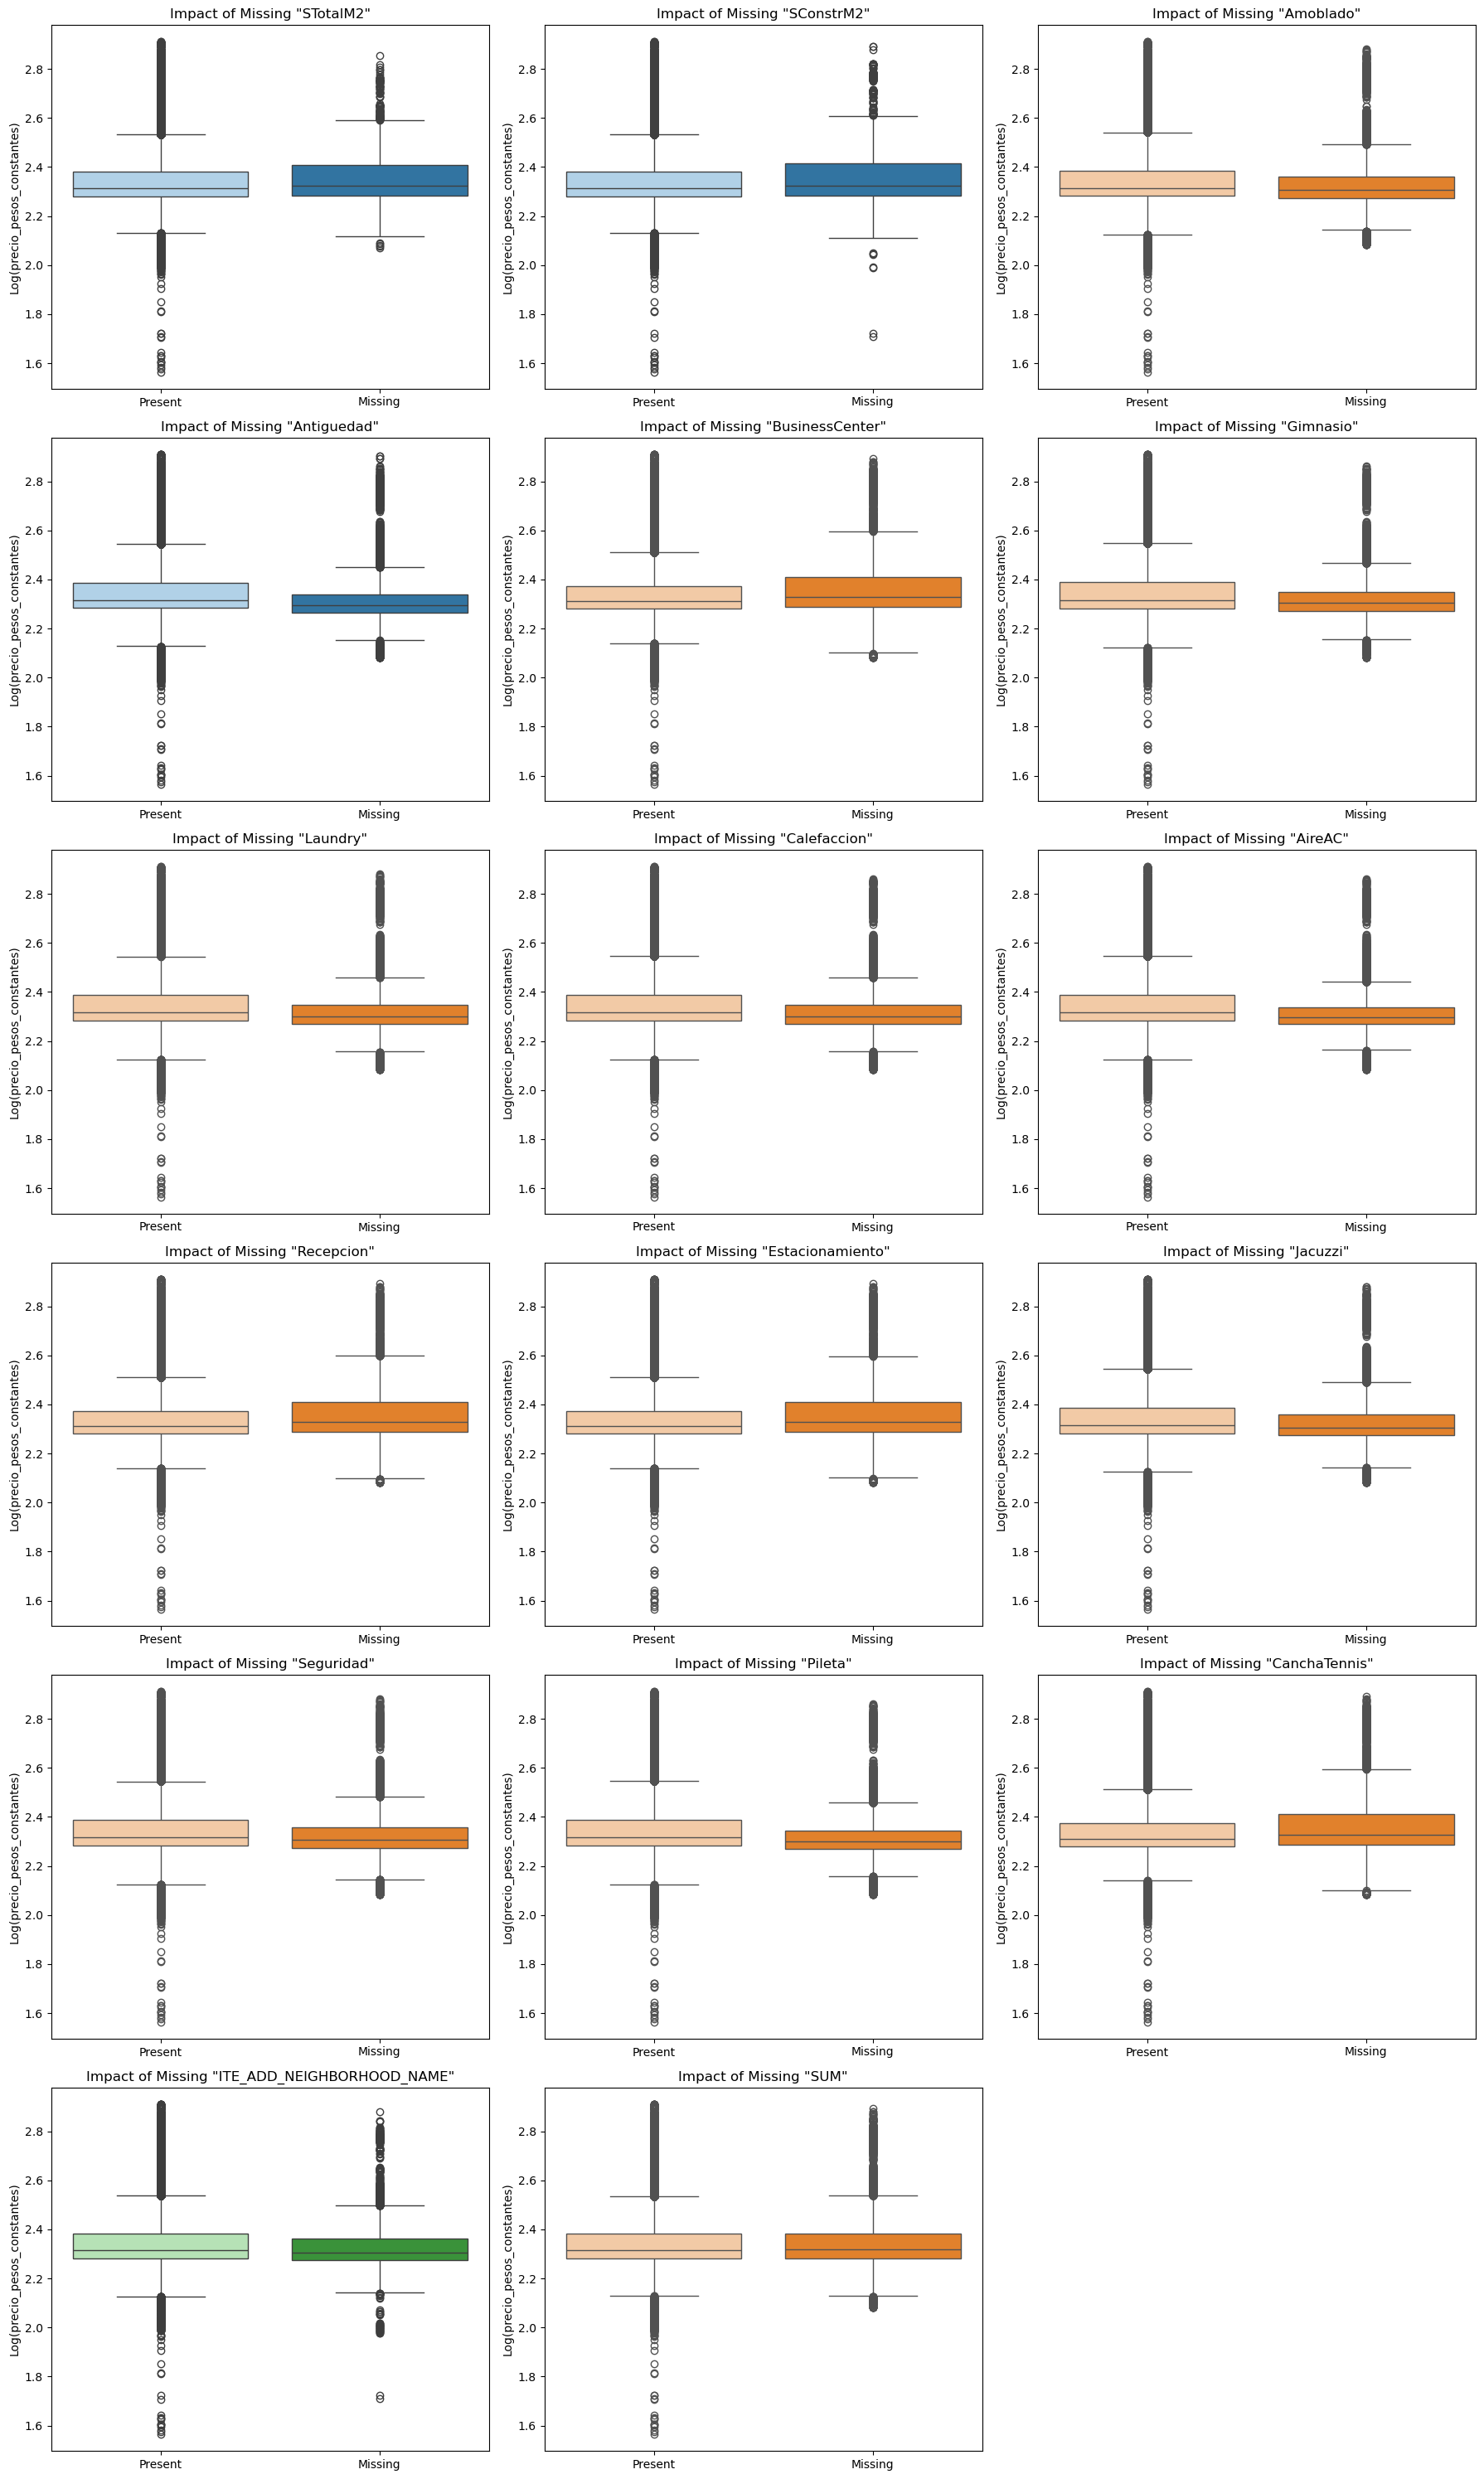

In [25]:
plot_missing_data_impact(df_std, numeric_cols=NUMERICAL_FEATURES, bool_cols=BOOLEAN_COLS, cat_cols=[COLS.BARRIO], target_col=TARGET, exclude_cols=[COLS.BANOS, COLS.COCHERAS, COLS.DORMITORIOS, COLS.AMBIENTES])

Las variables booleanas son las más problemáticas, con un gran porcentaje de datos faltantes que no podemos simplemente descartar. Lo mismo con las variables de superficie y de edad.

En cuanto al barrio, también hay una buena cantidad de datos faltantes, y esta feature es muy importante. Sin embargo, al ser demasiado grande la cantidad de barrios que hay, lo más probable es que no hagamos one hot encoding, ya que tendríamos una cantidad gigante de features solo para esta variable (más de 500). Lo que podríamos hacer es, por ejemplo, inputar con el precio medio del barrio, o algo similar. En este caso, será sencillo inputar los datos faltantes por ejemplo inputando por la media total del precio del dataset, o del precio de la ciudad por ejemplo.

En cuanto a las distribuciones del precio, esta es casi idéntica para los datos presentes y los faltantes, para las variables que fueron graficadas. La única diferencia que se ve en todos los casos es que la distribución del precio para los datos presentes tiene más outliers hacia abajo de la mediana que los datos ausentes.

Como las distribuciones son lago diferentes, sobre todo en los outliers, podríamos considerar, para las variables que fueron inputadas, agregar una nueva columna booleana que indique si esa variable fue inputada o no.

SUM tiene una cantidad enorme de datos faltantes y su impacto en el precio no es demasiado significativo, la podemos eliminar.

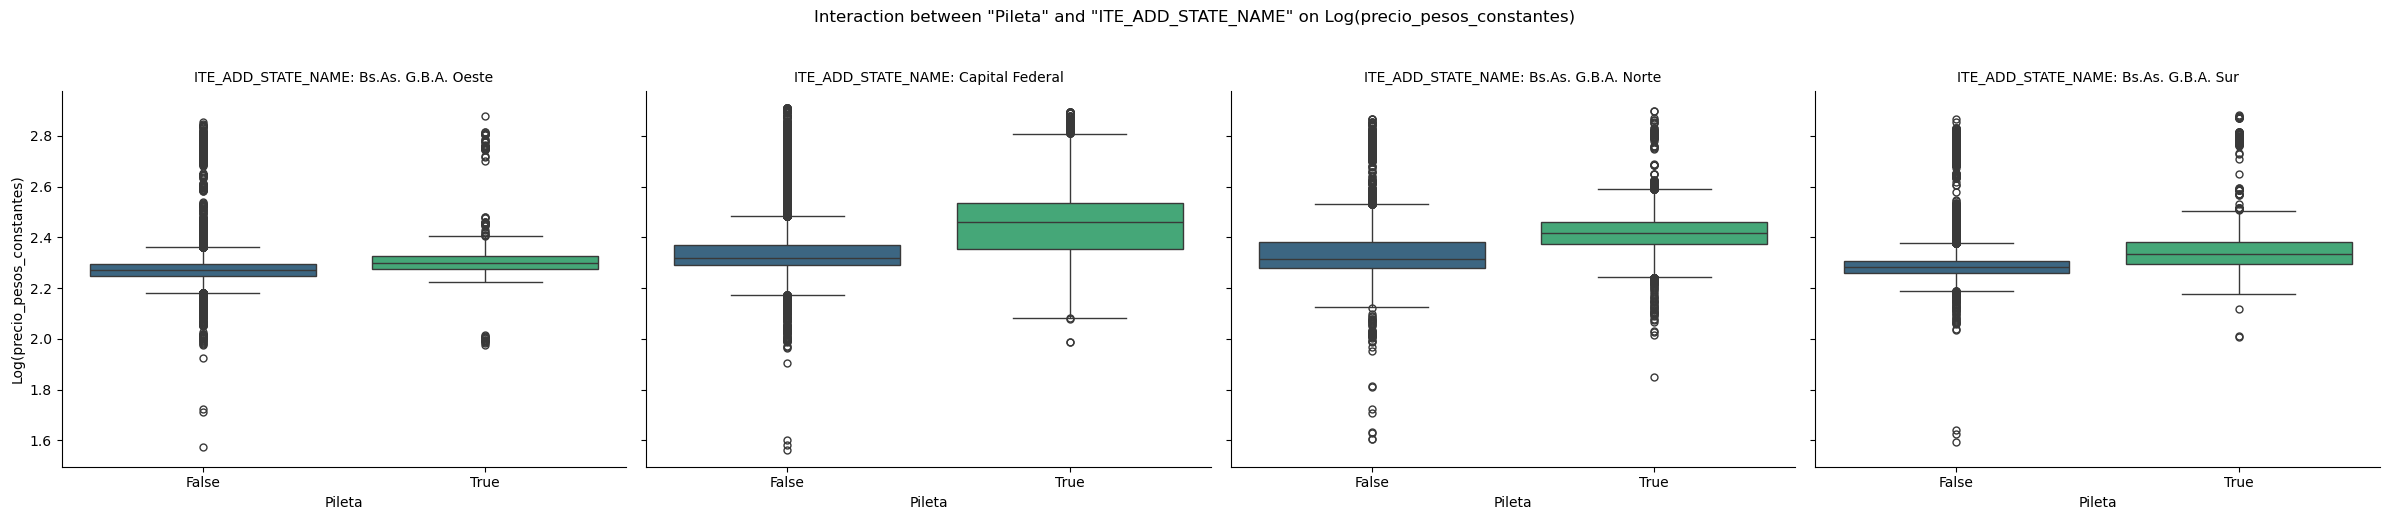

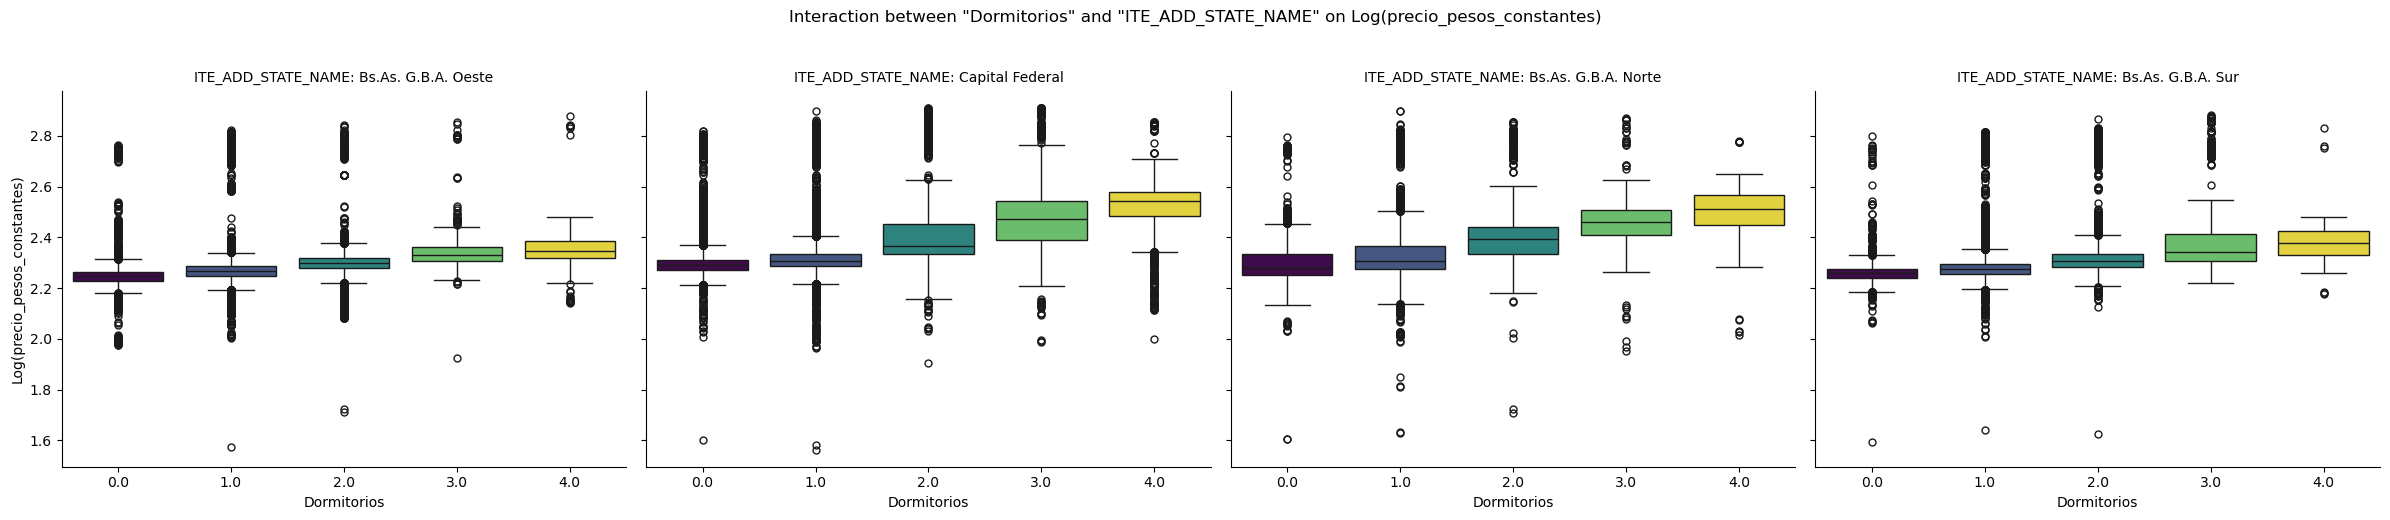

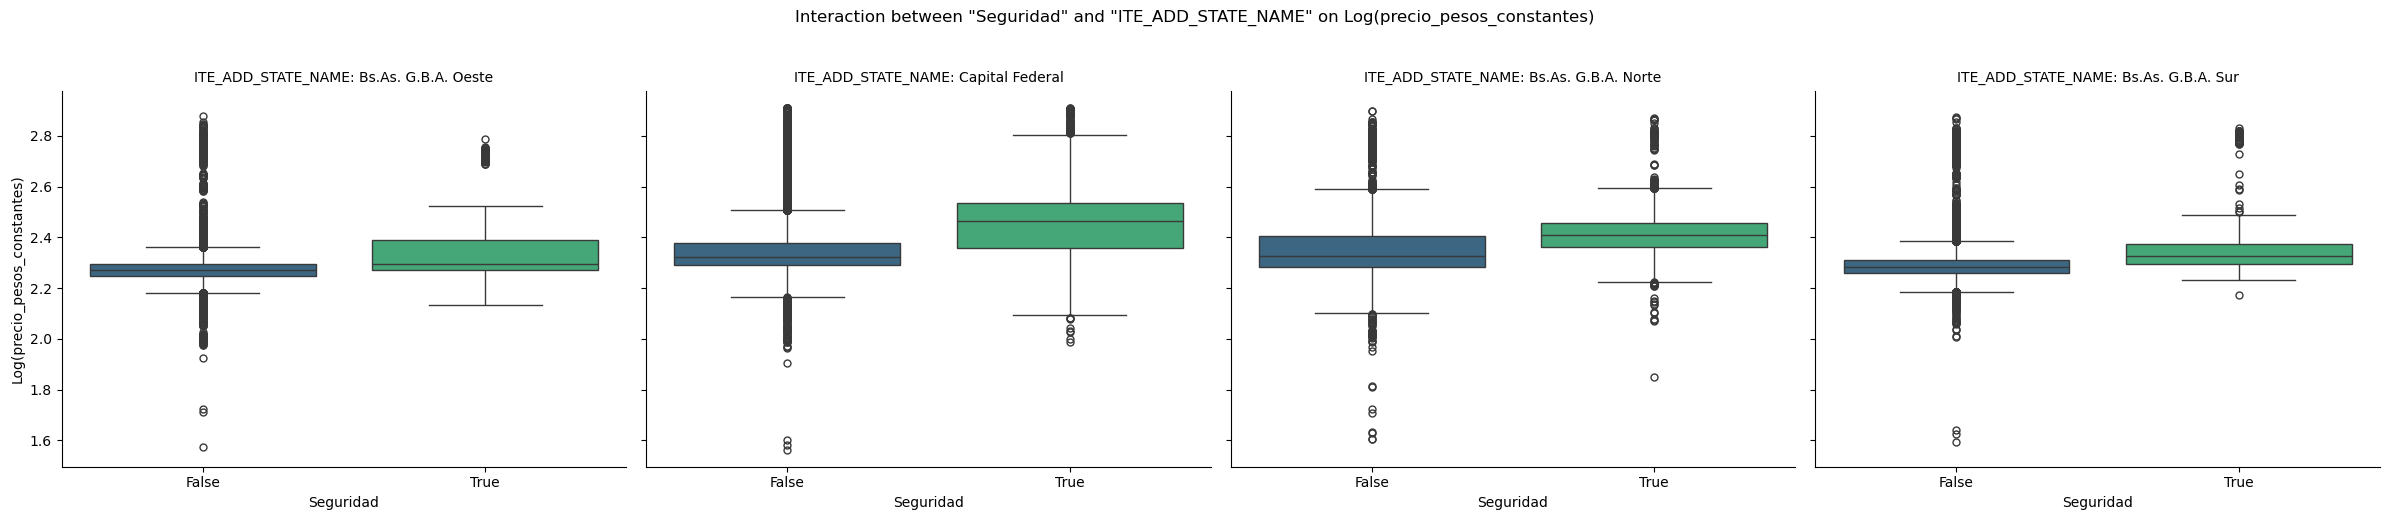

In [26]:
plot_interaction(
    df=df_std,
    target_col=COLS.TARGET,
    x_cols=[COLS.PILETA, COLS.DORMITORIOS, COLS.SEGURIDAD],
    facet_col=COLS.PROVINCIA
)

La mayoría de las features parecen tener un impacto distinto sobre el precio dependiendo de la zona. Para las 4 features probadas, todas tienen el impacto más grande en el precio si están en Capital, seguidas por Zona Norte.

# Conclusiones & Preprocesamiento

## Descubrimientos

### Precio
El target, precio_pesos_constantes, está extremadamente sesgado, con la gran mayoría de propiedades concentrándose en un rango de precios bajo, con una angosta cola de propiedades de muy alto valor. Una transformación logarítmica normaliza esta distribución, lo cual es más adecuado y útil para la mayoría de modelos. Los modelos, entonces, van a predecir el logaritmo del precio.

También se encontraron propiedades con precios extremadamente altos, que serán tratados mediante un clippeo en el percentil 0.98 para mitigar su efecto

### Variables numéricas
Al igual que con el precio, variables numéricas como STotalM2 y Antiguedad presentaron mucha asimetría. Clipear outliers y aplicar transformación logarítmica ayudó.

Hay otras variables numéricas como Dormitorios, Banos, Ambientes y Cocheras que también presentaban outliers extremadamente altos, imposibles para cualquier propiedad. Al clipear los outliers, estas variables se convirtieron en categóricas, con solo algunos valores únicos.

Finalmente, se detecto una muy alta correlación entre STotalM2 y SConstrM2 lo cual justifica eliminar una de ellas. Lo mismo con id_grid y LONGITUD.

### Análisis de impacto
El análisis de impacto reveló que las features relacionadas con la ubicación y las caracterísitcas principales de la propiedad (baños, dormitorios, etc) son las que tienen mayor impacto en el precio. Otras, como las relacionadas con la fecha de publicación, son las de menos impacto.

### Análisis de interacción con la ciudad
El análisis de interacción reveló que algunas features tienen más impacto si se encuentran en Capital Federal o Zona Norte que en otras zonas del AMBA.

### Patrón en datos faltantes
Las amenities booleanas son las más incompletas. En la mayoría de features, si bien la mediana del precio no varía significativamente entre datos presentes y faltantes, la distribución de outliers sí que lo hace. Esto nos indica que la falta de un dato no es _completamente_ aleatoria.


## Plan de preprocesamiento
En base a los descubrimientos mencionados, se optó por el siguiente plan de preprocesamiento

### Datos faltantes


- [x] Eliminar columnas:
    - id_grid: es exactamente igual a LATITUDE
    - STotalM2: correlación demasiado alta con SConstrM2


- [x] Agregar columnas:
    - Agregar columna SDescubiertaM2 = STotalM2 - SConstrM2


- [x] Imputar con False los datos faltantes en columnas booleanas
    - Amoblado, Gimnasio, Laundry, Calefaccion, AireAC, Seguridad, Pileta


- [x] Imputar con la mediana los datos faltantes en columnas numéricas
    - SConstrM2, SDescubiertaM2, Antiguedad

- [x] Imputar con la moda: Ambientes, Dormitorios, Cocheras, Banos


- [x] Para columnas imputadas, agregar columna que indique si el dato fue imputado o no.
    - Esto es debido a la diferencia en las distribuciones que encontramos para las muestras con datos faltantes
    - Para las columnas imputadas con la moda no hace falta esto, ya que son muy pocos los datos faltantes y vamos a agregar muchas columnas innecesariamente.


### Outliers
- [x] Clippear percentil 0.98:
    - SConstrM2, SDescubiertaM2, Antiguedad, Dormitorios, Banos, Ambientes, Cocheras, Precio

### Log transform
- [x] Transformación
    - Logarítmica SConstrM2, SDescubiertaM2, Antiguedad, Precio

### Estandarización
- [x] Estandarizar: SConstrM2, SDescubiertaM2, Antiguedad

### One-hot encoding
- [x] One-hot encoding de ITE_ADD_STATE_NAME, ITE_ADD_TIPO_PROD, year



Todo esto fue implementado en `src/pipeline.py`. Probemos cómo funciona:

In [27]:
# Cargamos df de nuevo para verificar que funcione
df_raw = pd.read_csv("../" + DEV_SET_CLEAN_PATH)

feature_pipeline = build_feature_pipeline(linear_models_pipeline_config)
target_pipeline = build_target_pipeline(linear_models_pipeline_config)

X = df_raw.drop(columns=[COLS.TARGET])

y = df_raw[[COLS.TARGET]]

X_transformed = feature_pipeline.fit_transform(X, y)
y_transformed = target_pipeline.fit_transform(y)


In [28]:
# Verificamos que las transformaciones hayan funcionado bien

feature_names = feature_pipeline.named_steps['preprocessor'].get_feature_names_out()
# Crear DataFrame legible
X_check = pd.DataFrame(X_transformed, columns=feature_names, index=X.index)
y_check = pd.DataFrame(y_transformed, columns=[COLS.TARGET], index=y.index)

In [29]:
X_check.head()

,discrete_numeric__Ambientes,discrete_numeric__Dormitorios,discrete_numeric__Banos,discrete_numeric__Cocheras,continuous_numeric__SConstrM2,continuous_numeric__SDescubiertaM2,continuous_numeric__Antiguedad,standard_scale__LONGITUDE,standard_scale__LATITUDE,categorical__ITE_ADD_STATE_NAME_Bs.As. G.B.A. Norte,...,boolean__BusinessCenter,boolean__Estacionamiento,boolean__SUM,boolean__Jacuzzi,remainder__ITE_ADD_CITY_NAME,remainder__ITE_ADD_NEIGHBORHOOD_NAME,remainder__mes_listing,remainder__Antiguedad_is_missing,remainder__SDescubiertaM2_is_missing,remainder__SConstrM2_is_missing
0,2.0,1.0,1.0,0.0,-0.676488,0.199316,-1.226011,-0.739665,-0.013339,0.0,...,False,False,False,False,Caseros,Caseros,8,False,False,False
1,2.0,1.0,1.0,0.0,-0.494015,0.784923,0.143842,0.063434,0.569666,0.0,...,False,False,False,False,Capital Federal,Núñez,4,False,False,False
2,3.0,1.0,1.0,0.0,0.29755,2.473019,1.220342,0.832957,-0.018073,0.0,...,False,False,False,False,Capital Federal,NaN,9,False,False,False
3,5.0,2.0,3.0,2.0,2.86298,-0.971897,1.364119,0.759272,0.16004,0.0,...,False,False,False,False,Capital Federal,Recoleta,11,False,False,False
4,5.0,2.0,4.0,0.0,2.86298,-0.971897,-1.226011,0.907185,-0.151956,0.0,...,False,False,False,False,Capital Federal,Monserrat,4,False,False,False


In [30]:
y_check.head()

,precio_pesos_constantes
0,8.745172
1,9.298754
2,9.289237
3,11.720004
4,12.546076
